# Experiment 1: Working with Python packages-Numpy, Scipy, Scikit-Learn, Matplotlib
Explore public repositories such as the UCI Machine Learning Repository (UCI Repository)
and Kaggle Datasets. Download the following datasets and identify the appropriate machine
learning model to be used (e.g., Supervised, Unsupervised, Semi-supervised, Regression, Classification) [CO1, K3].
 - Loan amount prediction
 - Handwritten character recognition
 - Classification of Email spam and MNIST data
 - Predicting Diabetes
 - Iris Dataset


## EDA function

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler


def eda(df):
    print("-" * 60)
    print("DATASET OVERVIEW")

    print("Dimensions:", df.shape)
    print("\nFirst 5 rows:")
    print(df.head())

    print("\nColumns:")
    for col in df.columns:
        print(col)

    dup = df.duplicated().sum()

    print("\nDuplicate rows:", dup)

    if dup > 0:
        df = df.drop_duplicates()
        print("Duplicate rows removed.")

    print("-" * 60)
    print("MISSING VALUE ANALYSIS")

    missing = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    print("\n")
    print(f"Number of missing values: {missing}")

    # Plot missing values
    plt.figure(figsize=(10, 5))
    plt.bar(df.columns, df.isnull().sum())
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.title("Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    
    #Remove columns with > 50% missing values
    
    missing_threshold = 50

    columns_to_drop = missing_percentage[missing_percentage > missing_threshold].index.tolist()

    if columns_to_drop:
        print("\nColumns removed because of excessive missing values:")
        for col in columns_to_drop: 
            print("column: " + col + " missing percentage: " + missing_percentage[col])
        df = df.drop(columns=columns_to_drop)

    else:
        print("\nNo columns have more than 50% missing values.")

    #Remove constant columns

    constant_columns = []    

    for col in df.columns:
            if df[col].nunique(dropna=False) <= 1:
                constant_columns.append(col)

    if constant_columns:
        print("\nConstant columns removed:")
        for col in constant_columns:
            print(col)
        df = df.drop(columns=constant_columns)

 
    #Seperate numerical and categorical features

    num_cols = df.select_dtypes(include=np.number).columns.tolist()

    cat_cols = df.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

    print("\nNumerical columns:")
    print(num_cols)

    print("\nCategorical columns:")
    print(cat_cols)

    
    #Missing value imputation
    
    print("-" * 60)
    print("MISSING VALUE IMPUTATION")

    for col in num_cols:
        if df[col].isnull().sum() > 0:
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)

    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            mode = df[col].mode()
            if not mode.empty:
                mode_value = mode[0]
                df[col] = df[col].fillna(mode_value)

    print("Missing values imputed!")

    
    # outlier handling
    

    print("-" * 60)
    print("OUTLIER DETECTION")

    
    outlier_percentage_threshold = 15

    for col in num_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_df = (
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        )
        out_cnt = outlier_df.sum()
        outlier_percentage = (out_cnt / len(df)) * 100
        print(f"{col}: {out_cnt} outliers, percentage: {outlier_percentage}")

        if outlier_percentage == 0:
            print("No outliers detected.")

        elif outlier_percentage <= outlier_percentage_threshold:
            median_value = df[col].median()
            df.loc[outlier_df, col] = median_value

            print("Few outliers detected.")
            print(f"Replaced with median ({median_value}).")

        elif outlier_percentage >= outlier_percentage_threshold:

            df.loc[df[col] < lower_bound, col] = lower_bound
            df.loc[df[col] > upper_bound, col] = upper_bound

            print("Moderate outliers detected.")
            print("Values changed to IQR boundaries")

    print("-" * 60)
    print("NUMERICAL FEATURES VISUALIZATION")
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f"{col} - Distribution")
        axes[0].set_xlabel(col)

        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f"{col} - Boxplot")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

    # Numerical feature analysis

    print("-" * 60)
    print("NUMERICAL FEATURE TRANSFORMATION")

    for col in num_cols:
        skewness = df[col].skew()
        print(f"{col}: skewness = {skewness}")
        if abs(skewness) > 1:
            if (df[col] >= 0).all():
                df[col] = np.log1p(df[col])
                print("Highly skewed and non-negative.")
                print("Applied log1p transformation.")
            else:
                scaler = StandardScaler()
                df[[col]] = scaler.fit_transform(df[[col]])

                print("Highly skewed but contains negative values. Applied StandardScaler.")
        else:
            scaler = StandardScaler()
            df[[col]] = scaler.fit_transform(df[[col]])
            print("Distribution is reasonably symmetric.")
            print("Applied StandardScaler.")

    #Categorical feature analysis

    print("-" * 60)
    print("CATEGORICAL FEATURE ANALYSIS")

    for col in cat_cols:
        counts = df[col].value_counts()

        plt.figure(figsize=(8, 5))

        sns.countplot(
            data=df,
            x=col,
            order=counts.index
        )

        plt.title(f"Count Plot - {col}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    
    # Encode categorical values
    
    print("-" * 60)
    print("CATEGORICAL ENCODING")

    for col in cat_cols:
        unique_count = df[col].nunique()
        if unique_count == 2:
            values = df[col].unique()
            mapping = {values[0]: 0, values[1]: 1}
            df[col] = df[col].map(mapping)
            print(f"{col}: Binary encoding -> {mapping}")

        else:

            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
            df = pd.concat([df.drop(columns=[col]), dummies],axis=1)
            print(f"{col}: One-hot encoded ")
            print(f"{unique_count} categories")


    # Final dataset

    print("-" * 60)
    print("FINAL DATASET")

    print("Final dimensions:", df.shape)

    print("Remaining columns:")
    print(df.columns.tolist())

    print("Remaining missing values:")
    print(df.isnull().sum())

    print("Final dataframe:")
    print(df.head())

    return df

## 1. Iris Dataset

------------------------------------------------------------
DATASET OVERVIEW
Dimensions: (150, 6)

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Columns:
Id
SepalLengthCm
SepalWidthCm
PetalLengthCm
PetalWidthCm
Species

Duplicate rows: 0
------------------------------------------------------------
MISSING VALUE ANALYSIS


Number of missing values: Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


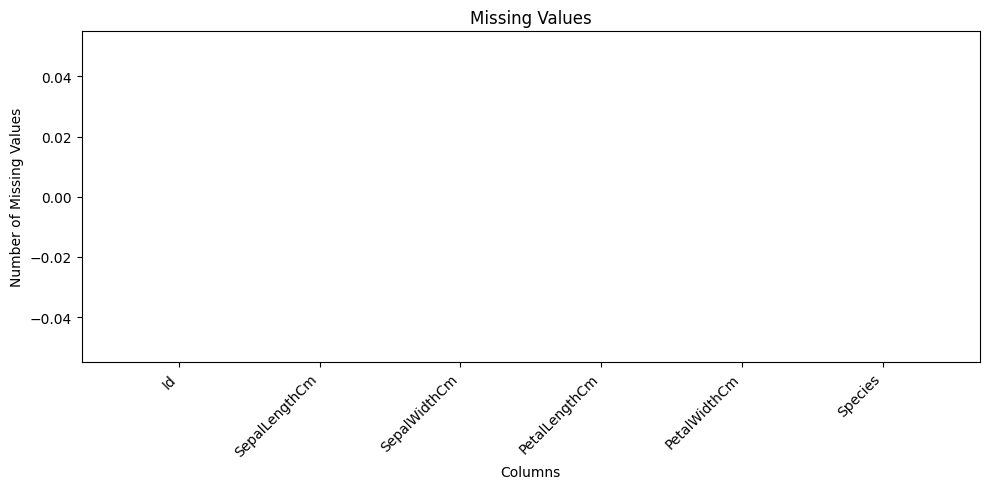


No columns have more than 50% missing values.

Numerical columns:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Categorical columns:
['Species']
------------------------------------------------------------
MISSING VALUE IMPUTATION
Missing values imputed!
------------------------------------------------------------
OUTLIER DETECTION
Id: 0 outliers, percentage: 0.0
No outliers detected.
SepalLengthCm: 0 outliers, percentage: 0.0
No outliers detected.
SepalWidthCm: 4 outliers, percentage: 2.666666666666667
Few outliers detected.
Replaced with median (3.0).
PetalLengthCm: 0 outliers, percentage: 0.0
No outliers detected.
PetalWidthCm: 0 outliers, percentage: 0.0
No outliers detected.
------------------------------------------------------------
NUMERICAL FEATURES VISUALIZATION


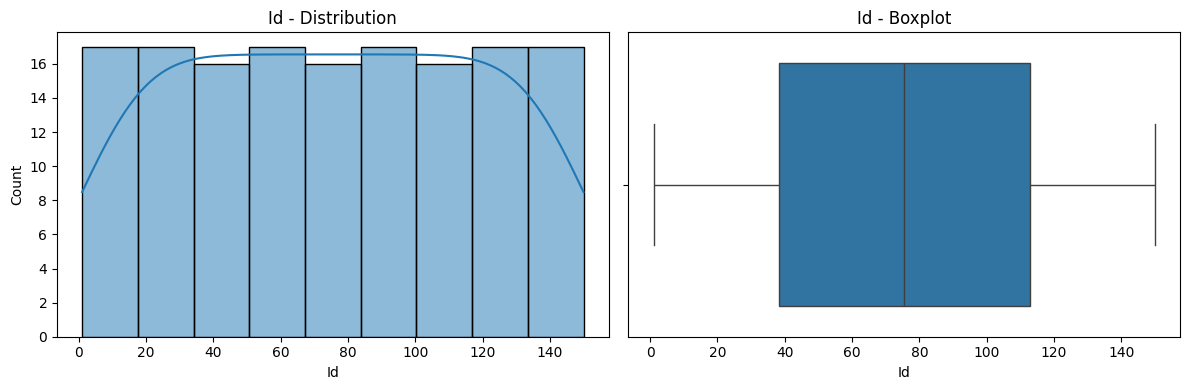

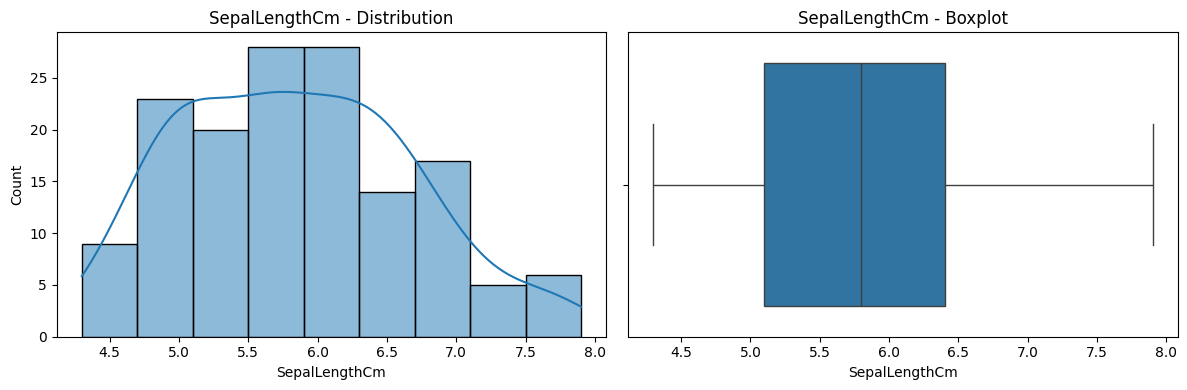

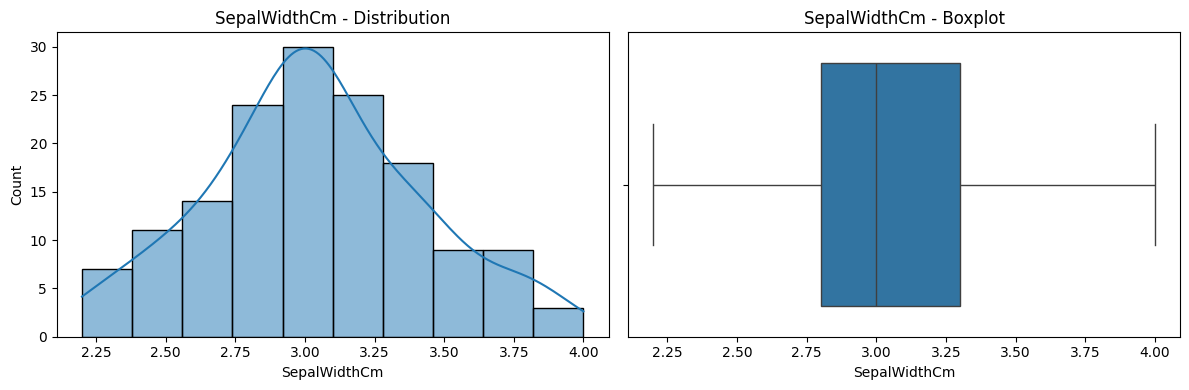

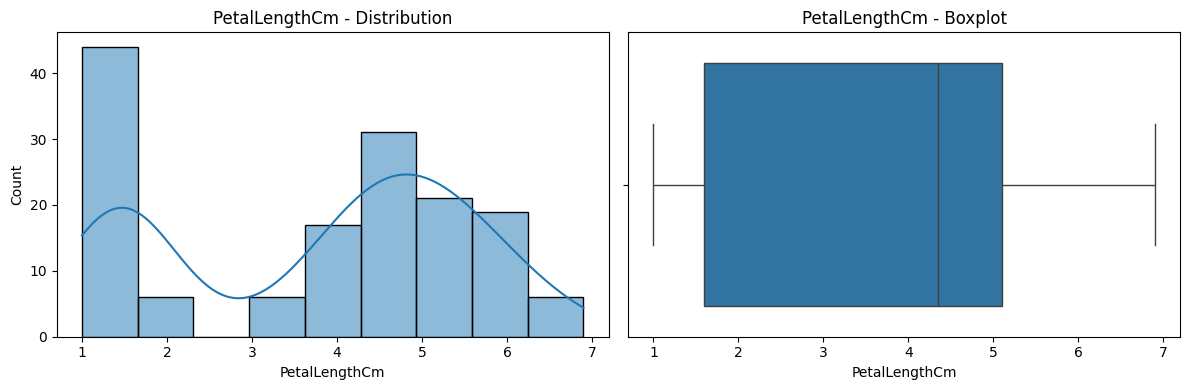

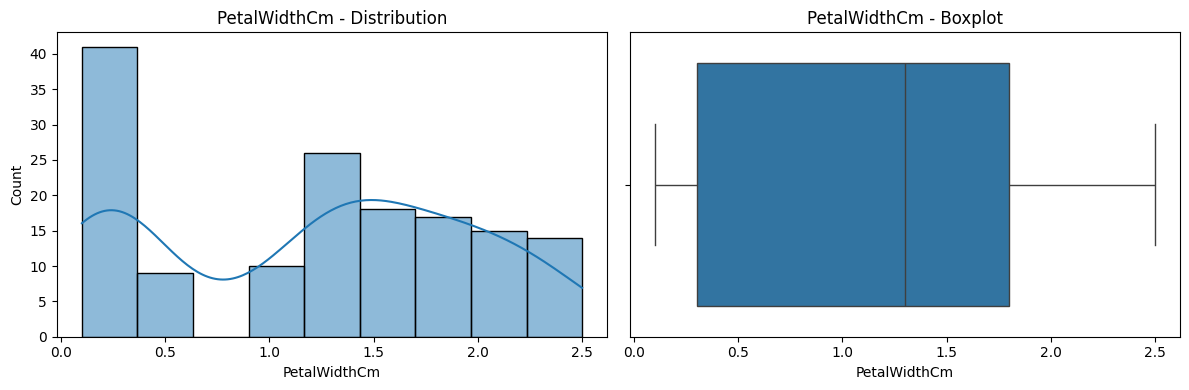

------------------------------------------------------------
NUMERICAL FEATURE TRANSFORMATION
Id: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
SepalLengthCm: skewness = 0.3149109566369728
Distribution is reasonably symmetric.
Applied StandardScaler.
SepalWidthCm: skewness = 0.1503067216222139
Distribution is reasonably symmetric.
Applied StandardScaler.
PetalLengthCm: skewness = -0.27446425247378287
Distribution is reasonably symmetric.
Applied StandardScaler.
PetalWidthCm: skewness = -0.10499656214412734
Distribution is reasonably symmetric.
Applied StandardScaler.
------------------------------------------------------------
CATEGORICAL FEATURE ANALYSIS


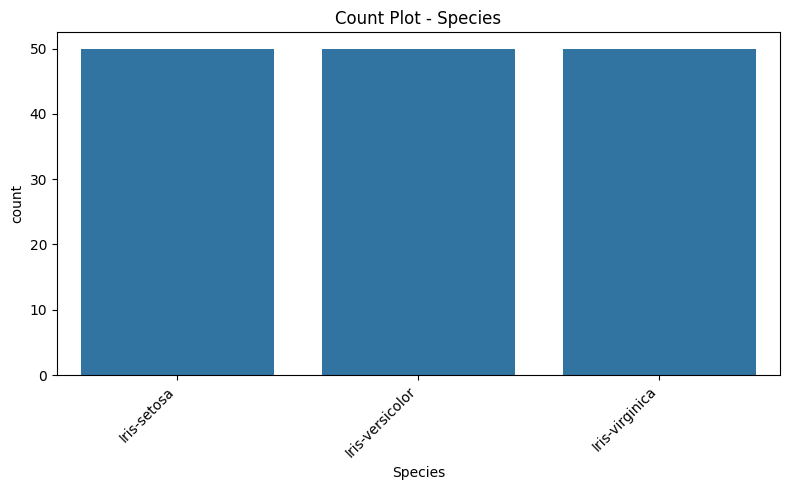

------------------------------------------------------------
CATEGORICAL ENCODING
Species: One-hot encoded 
3 categories
------------------------------------------------------------
FINAL DATASET
Final dimensions: (150, 7)
Remaining columns:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species_Iris-versicolor', 'Species_Iris-virginica']
Remaining missing values:
Id                         0
SepalLengthCm              0
SepalWidthCm               0
PetalLengthCm              0
PetalWidthCm               0
Species_Iris-versicolor    0
Species_Iris-virginica     0
dtype: int64
Final dataframe:
         Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0 -1.720542      -0.900681      1.194185      -1.341272     -1.312977   
1 -1.697448      -1.143017     -0.092652      -1.341272     -1.312977   
2 -1.674353      -1.385353      0.422083      -1.398138     -1.312977   
3 -1.651258      -1.506521      0.164715      -1.284407     -1.312977   
4 -1.628

In [3]:
df_iris = pd.read_csv("Iris.csv")
df_iris = eda(df_iris)

## 2. Loan Amount Prediction 

------------------------------------------------------------
DATASET OVERVIEW
Dimensions: (367, 12)

First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History Property_Area  
0        

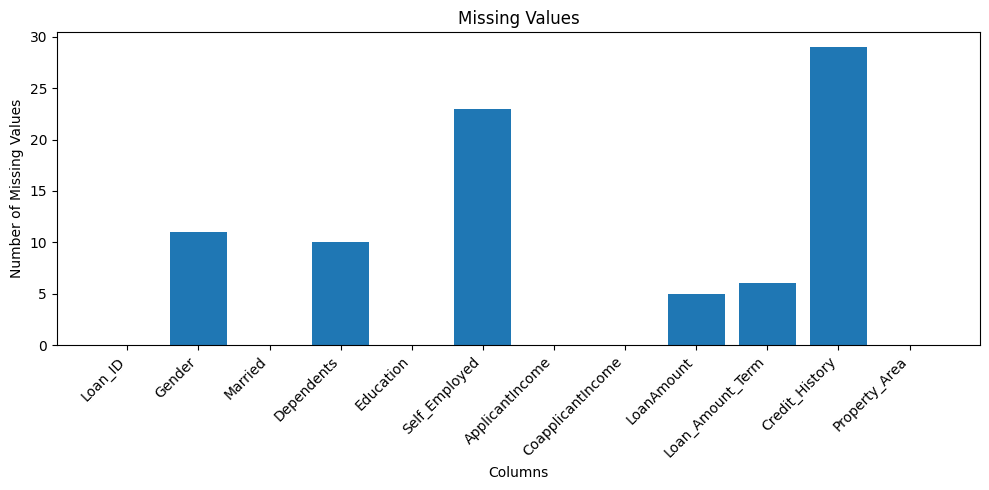


No columns have more than 50% missing values.

Numerical columns:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
------------------------------------------------------------
MISSING VALUE IMPUTATION
Missing values imputed!
------------------------------------------------------------
OUTLIER DETECTION
ApplicantIncome: 32 outliers, percentage: 8.71934604904632
Few outliers detected.
Replaced with median (3786.0).
CoapplicantIncome: 8 outliers, percentage: 2.17983651226158
Few outliers detected.
Replaced with median (1025.0).
LoanAmount: 18 outliers, percentage: 4.904632152588556
Few outliers detected.
Replaced with median (125.0).
Loan_Amount_Term: 50 outliers, percentage: 13.623978201634879
Few outliers detected.
Replaced with median (360.0).
Credit_History: 59 outliers, percentage: 16.076294277929154
Moderate outliers detecte

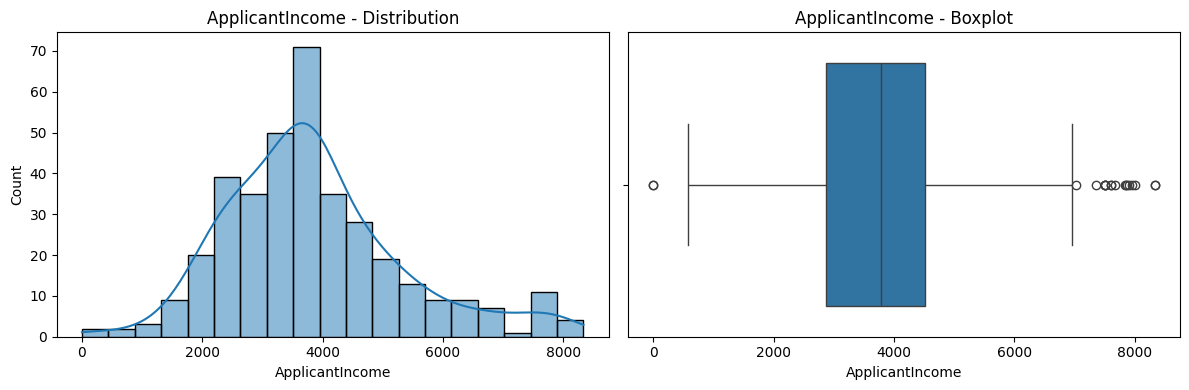

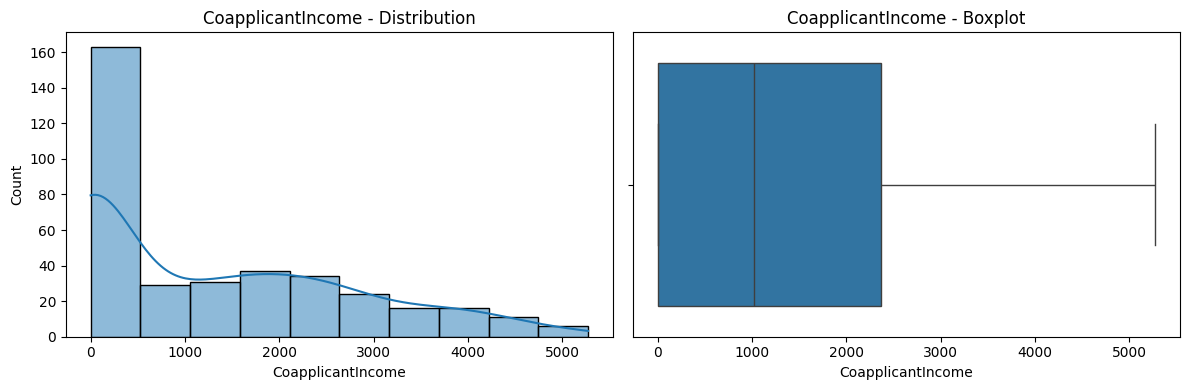

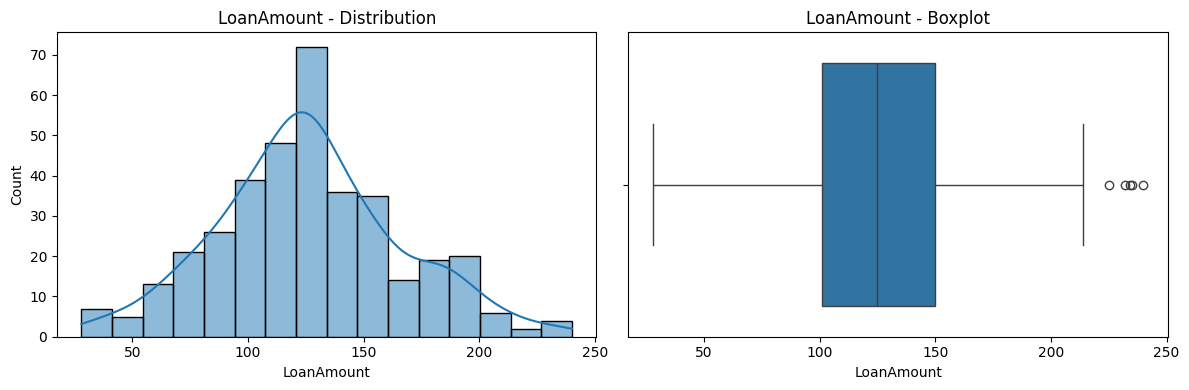

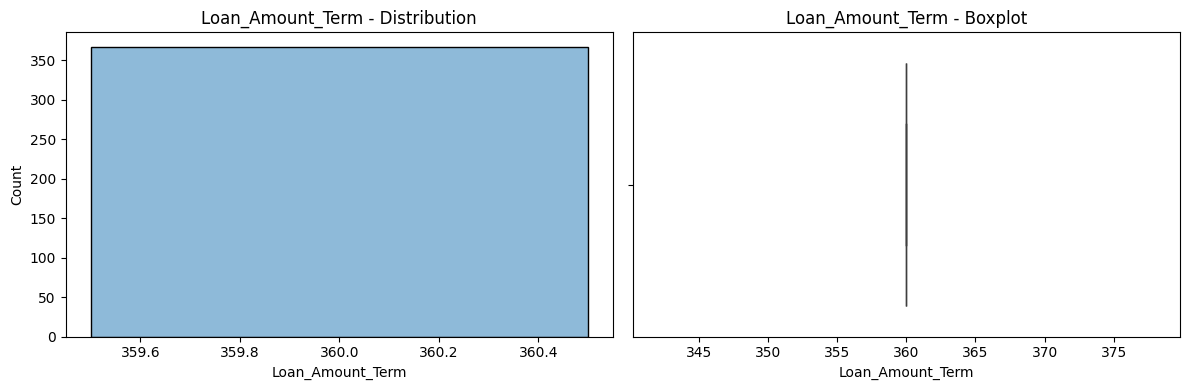

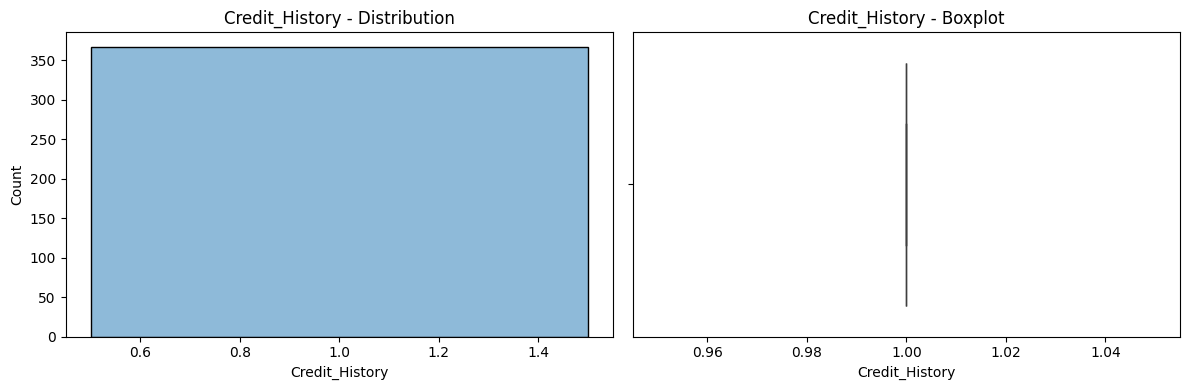

------------------------------------------------------------
NUMERICAL FEATURE TRANSFORMATION
ApplicantIncome: skewness = 0.753553594617475
Distribution is reasonably symmetric.
Applied StandardScaler.
CoapplicantIncome: skewness = 0.773721306907611
Distribution is reasonably symmetric.
Applied StandardScaler.
LoanAmount: skewness = 0.2174049064246975
Distribution is reasonably symmetric.
Applied StandardScaler.
Loan_Amount_Term: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
Credit_History: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
------------------------------------------------------------
CATEGORICAL FEATURE ANALYSIS


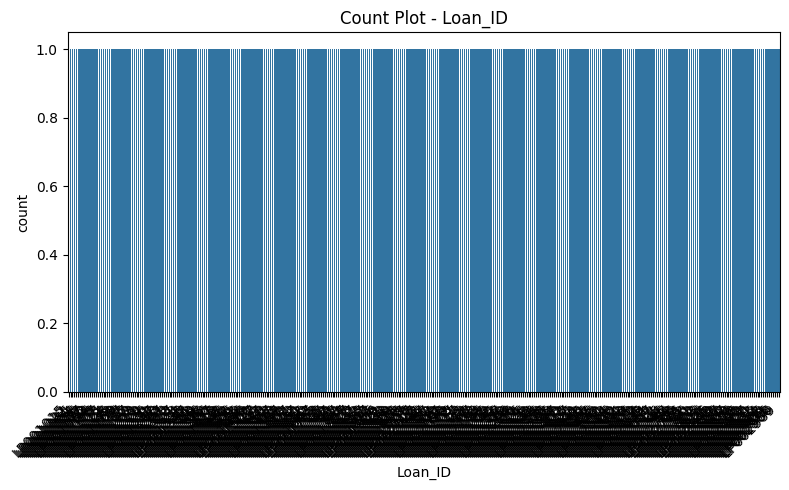

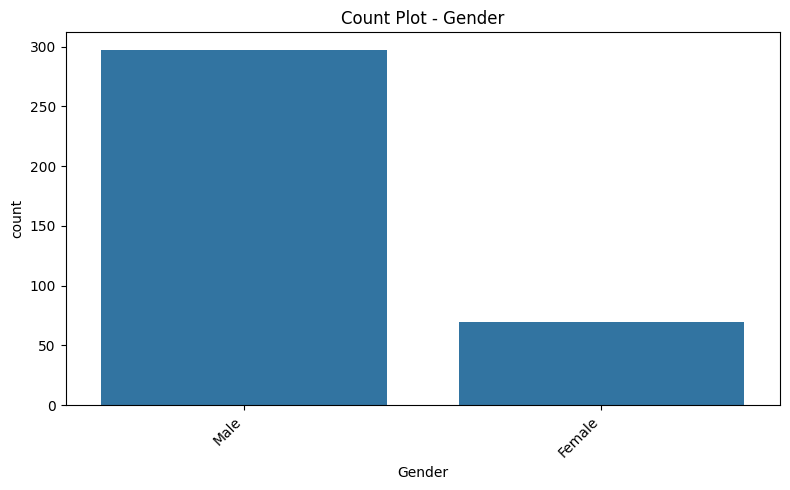

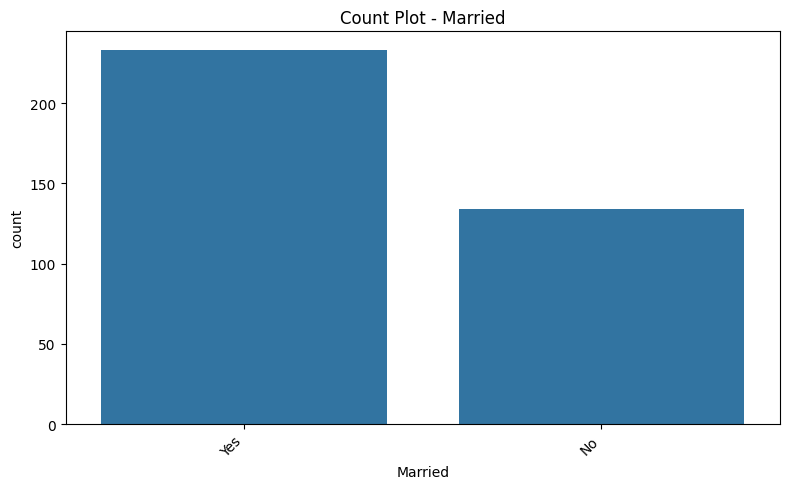

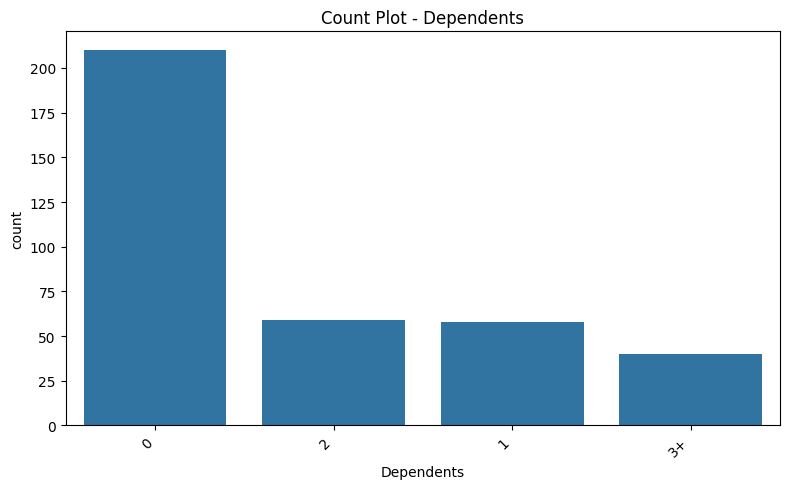

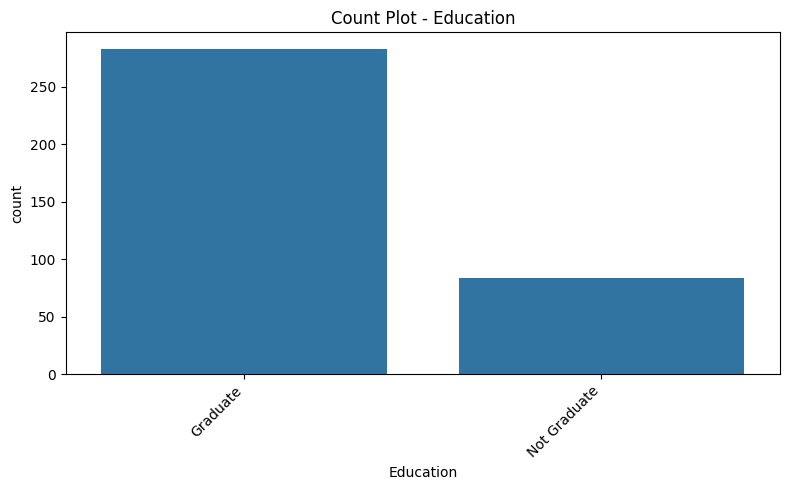

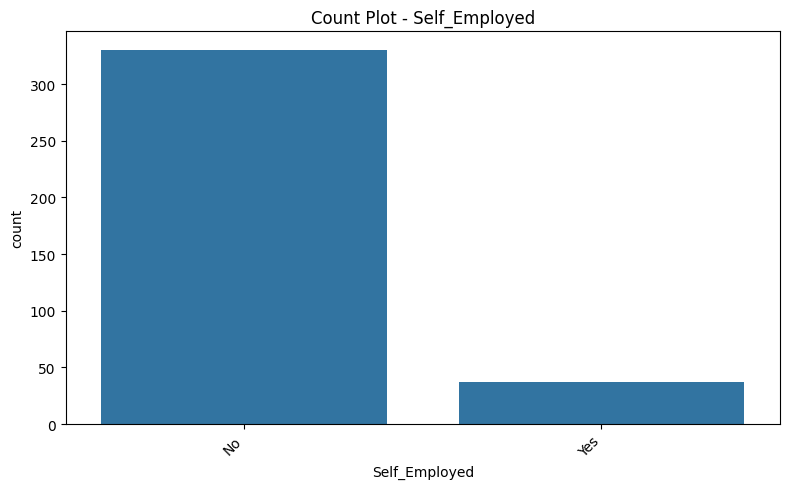

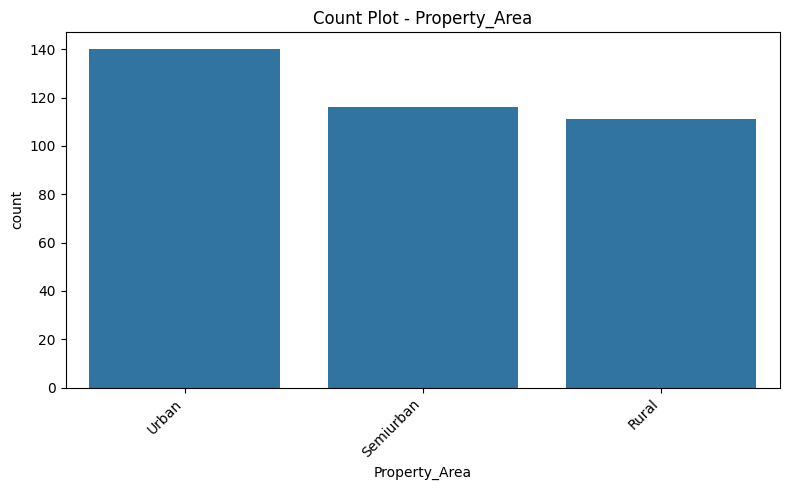

------------------------------------------------------------
CATEGORICAL ENCODING
Loan_ID: One-hot encoded 
367 categories
Gender: Binary encoding -> {'Male': 0, 'Female': 1}
Married: Binary encoding -> {'Yes': 0, 'No': 1}
Dependents: One-hot encoded 
4 categories
Education: Binary encoding -> {'Graduate': 0, 'Not Graduate': 1}
Self_Employed: Binary encoding -> {'No': 0, 'Yes': 1}
Property_Area: One-hot encoded 
3 categories
------------------------------------------------------------
FINAL DATASET
Final dimensions: (367, 380)
Remaining columns:
['Gender', 'Married', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_ID_LP001022', 'Loan_ID_LP001031', 'Loan_ID_LP001035', 'Loan_ID_LP001051', 'Loan_ID_LP001054', 'Loan_ID_LP001055', 'Loan_ID_LP001056', 'Loan_ID_LP001059', 'Loan_ID_LP001067', 'Loan_ID_LP001078', 'Loan_ID_LP001082', 'Loan_ID_LP001083', 'Loan_ID_LP001094', 'Loan_ID_LP001096', 'Loan_ID_LP001099', 'Loa

In [4]:
data = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')
data = eda(data)

## 3. Predicting Diabetes

------------------------------------------------------------
DATASET OVERVIEW
Dimensions: (100000, 9)

First 5 rows:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Columns:
gender
age
hypertension
heart_disease
smoking_history
bmi
HbA1c_level
blood_glucose_level
diabetes

Duplicate rows: 3854
Duplicate rows removed.
-------------

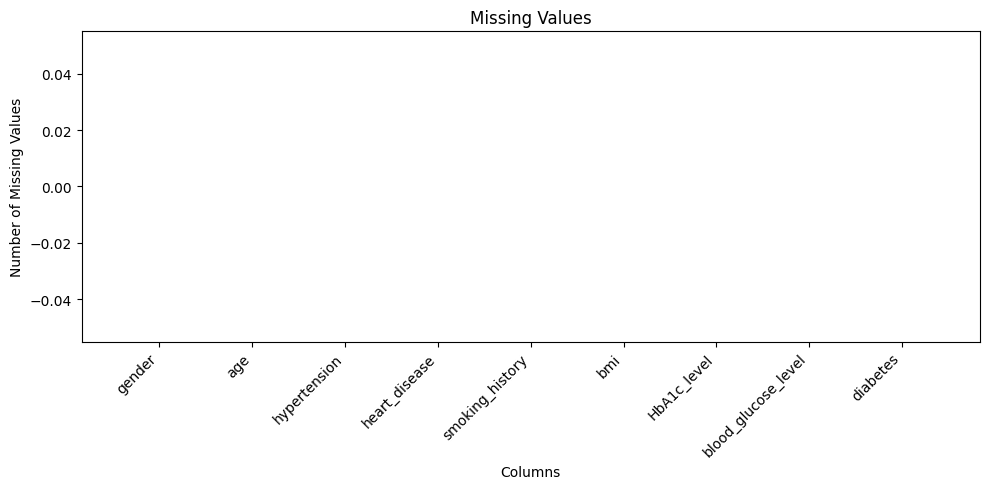


No columns have more than 50% missing values.

Numerical columns:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Categorical columns:
['gender', 'smoking_history']
------------------------------------------------------------
MISSING VALUE IMPUTATION
Missing values imputed!
------------------------------------------------------------
OUTLIER DETECTION
age: 0 outliers, percentage: 0.0
No outliers detected.
hypertension: 7461 outliers, percentage: 7.7600732219749124
Few outliers detected.
Replaced with median (0.0).
heart_disease: 3923 outliers, percentage: 4.080252948640609
Few outliers detected.
Replaced with median (0.0).
bmi: 5354 outliers, percentage: 5.568614398934954
Few outliers detected.
Replaced with median (27.32).
HbA1c_level: 1312 outliers, percentage: 1.3645913506542133
Few outliers detected.
Replaced with median (5.8).
blood_glucose_level: 2031 outliers, percentage: 2.1124123728496245
Few outliers detected.
Replaced with 

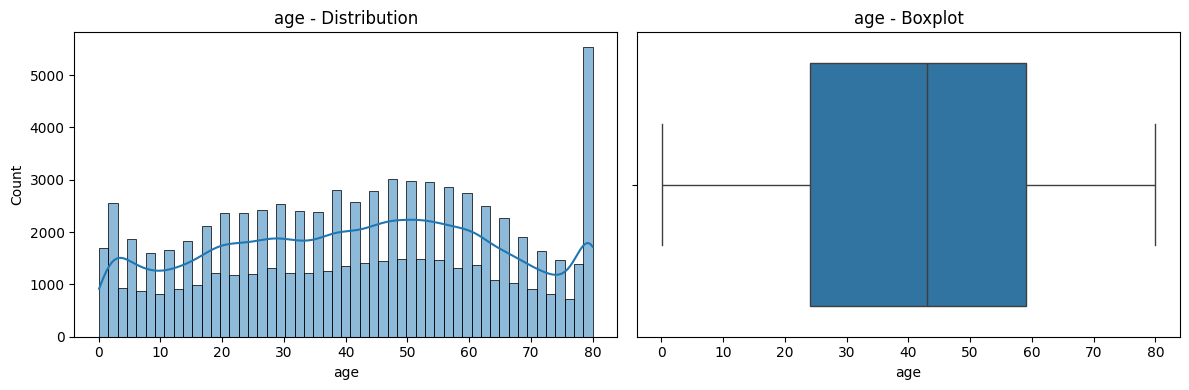

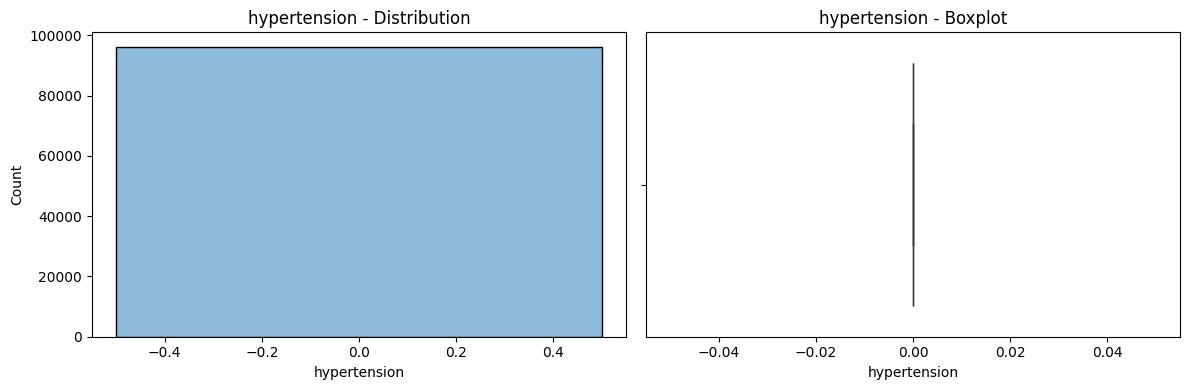

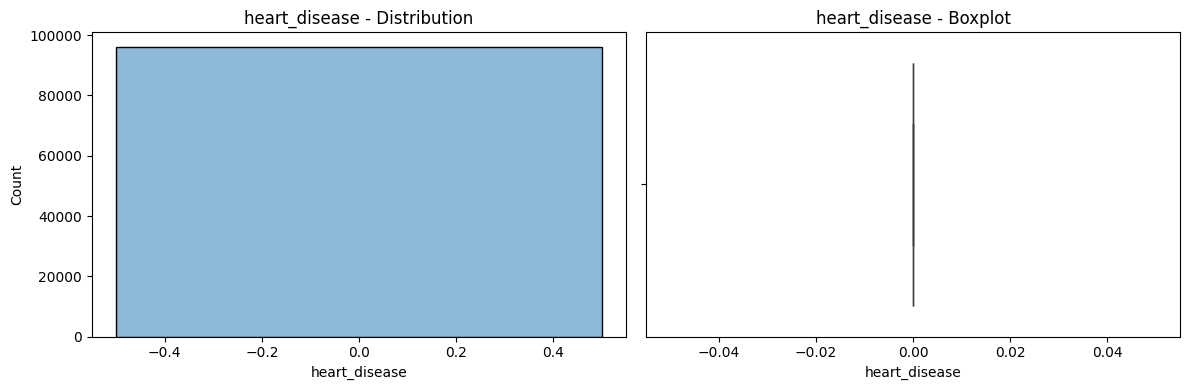

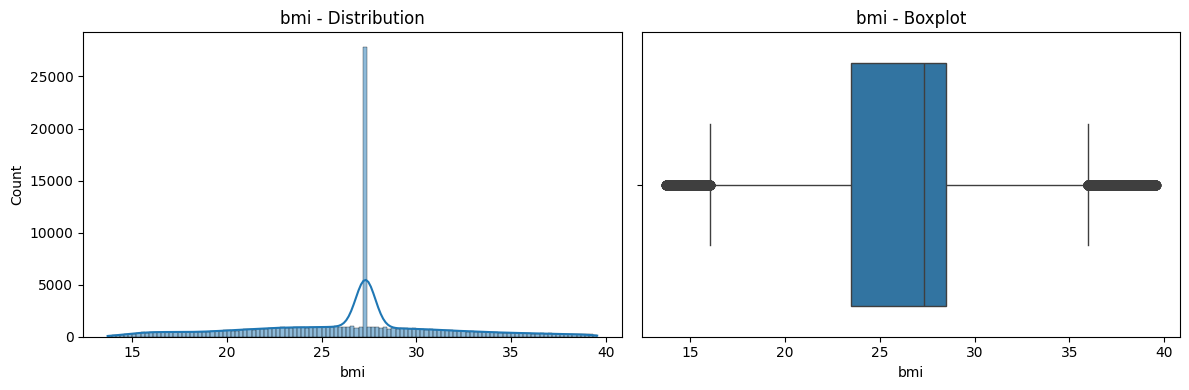

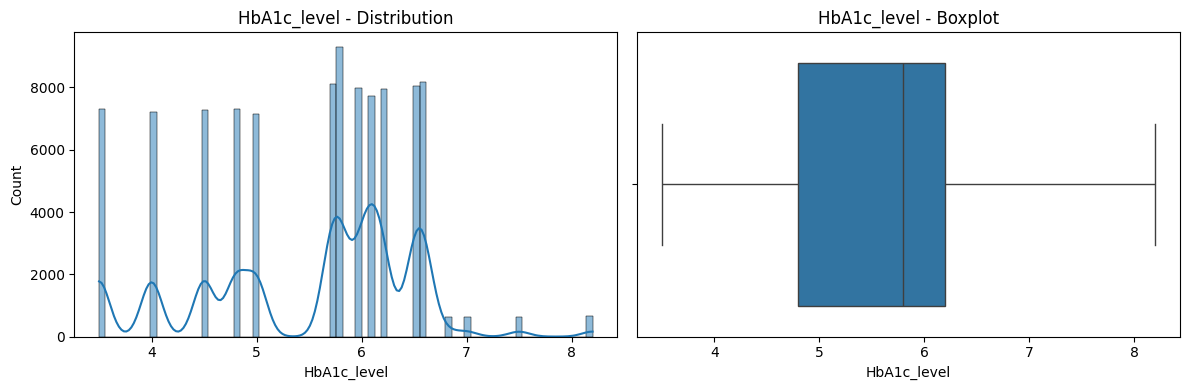

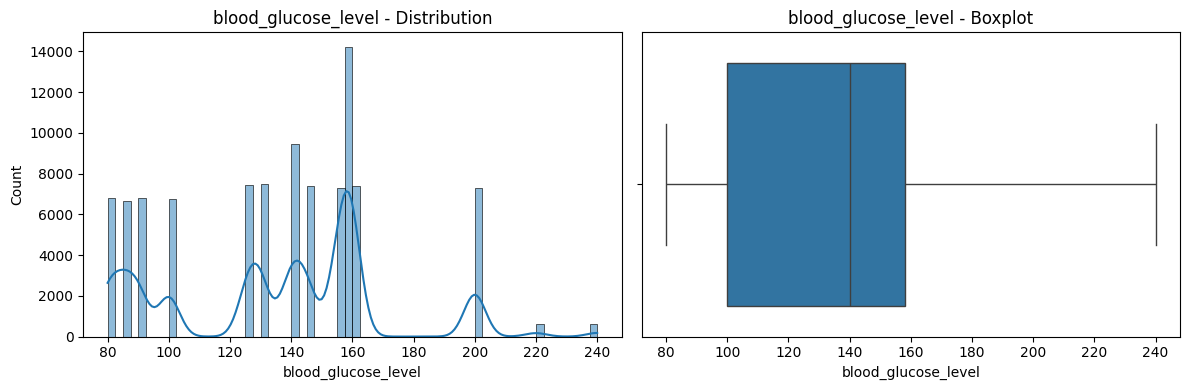

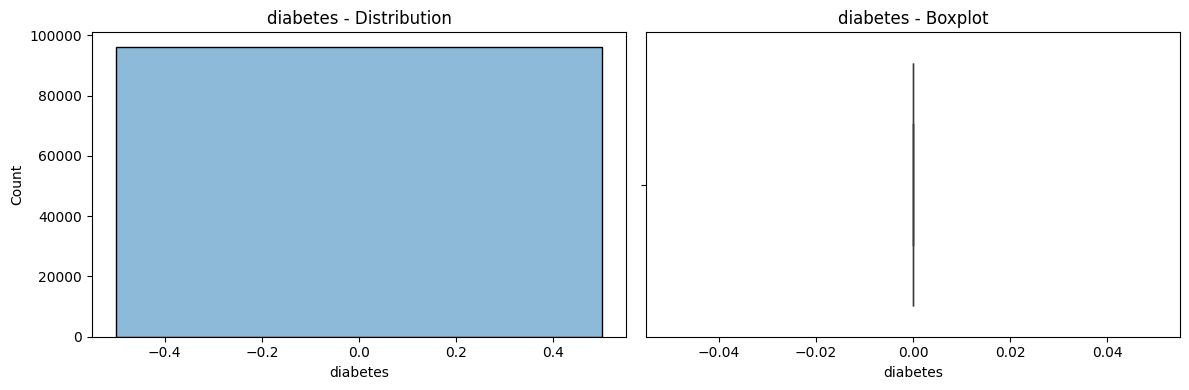

------------------------------------------------------------
NUMERICAL FEATURE TRANSFORMATION
age: skewness = -0.06244473606084344
Distribution is reasonably symmetric.
Applied StandardScaler.
hypertension: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
heart_disease: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
bmi: skewness = -0.07135256489003797
Distribution is reasonably symmetric.
Applied StandardScaler.
HbA1c_level: skewness = -0.4654068975645631
Distribution is reasonably symmetric.
Applied StandardScaler.
blood_glucose_level: skewness = 0.12133089015732217
Distribution is reasonably symmetric.
Applied StandardScaler.
diabetes: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
------------------------------------------------------------
CATEGORICAL FEATURE ANALYSIS


C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_48392\3500902641.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[[col]] = scaler.fit_transform(df[[col]])
C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_48392\3500902641.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[[col]] = scaler.fit_transform(df[[col]])
C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_48392\3500902641.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

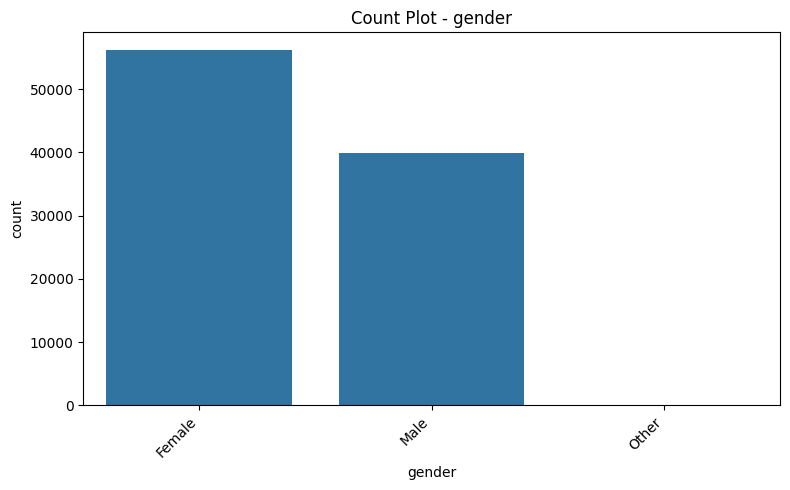

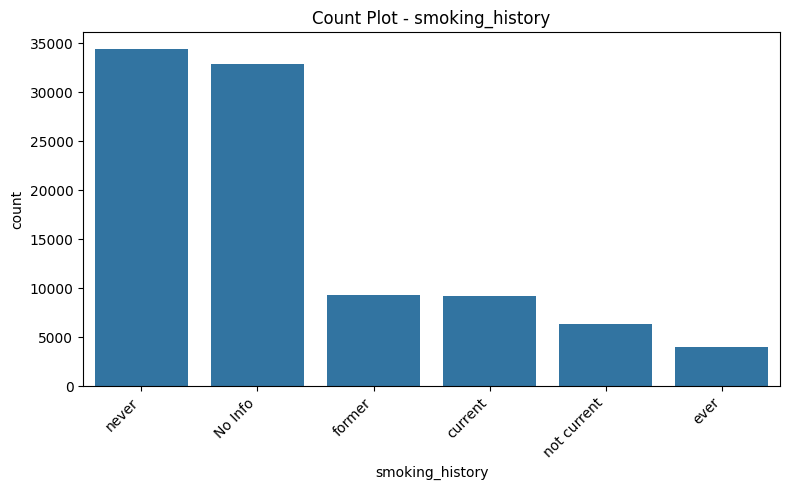

------------------------------------------------------------
CATEGORICAL ENCODING
gender: One-hot encoded 
3 categories
smoking_history: One-hot encoded 
6 categories
------------------------------------------------------------
FINAL DATASET
Final dimensions: (96146, 14)
Remaining columns:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'gender_Male', 'gender_Other', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']
Remaining missing values:
age                            0
hypertension                   0
heart_disease                  0
bmi                            0
HbA1c_level                    0
blood_glucose_level            0
diabetes                       0
gender_Male                    0
gender_Other                   0
smoking_history_current        0
smoking_history_ever           0
smoking_history_former         0
smoking_history_never    

In [5]:
df_diabetes = pd.read_csv("diabetes_prediction_dataset.csv")
df_diabetes = eda(df_diabetes)

## 4. Classification of Email Spam

------------------------------------------------------------
DATASET OVERVIEW
Dimensions: (4601, 58)

First 5 rows:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word

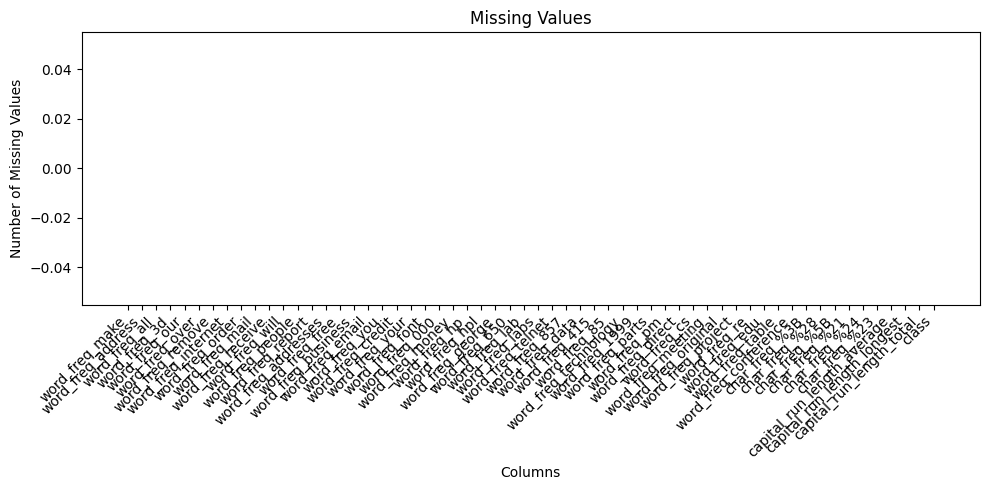


No columns have more than 50% missing values.

Numerical columns:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%2

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_48392\3500902641.py:143: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '101.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[outlier_df, col] = median_value


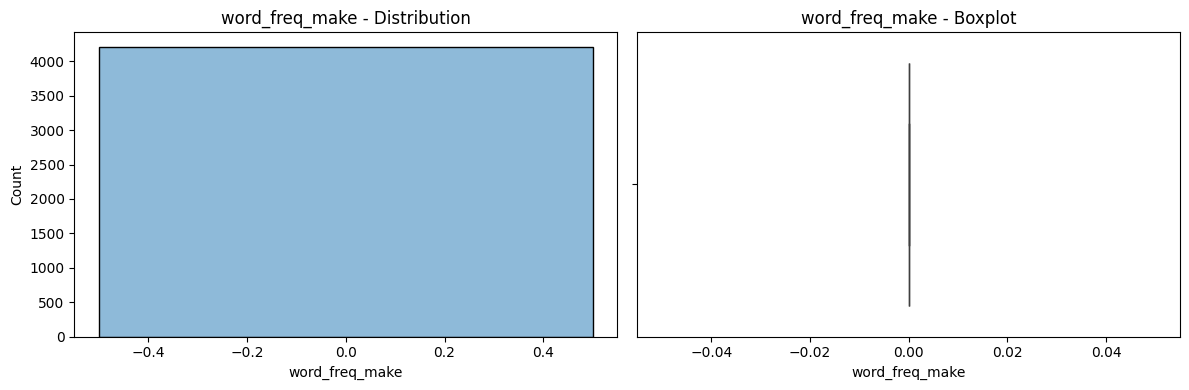

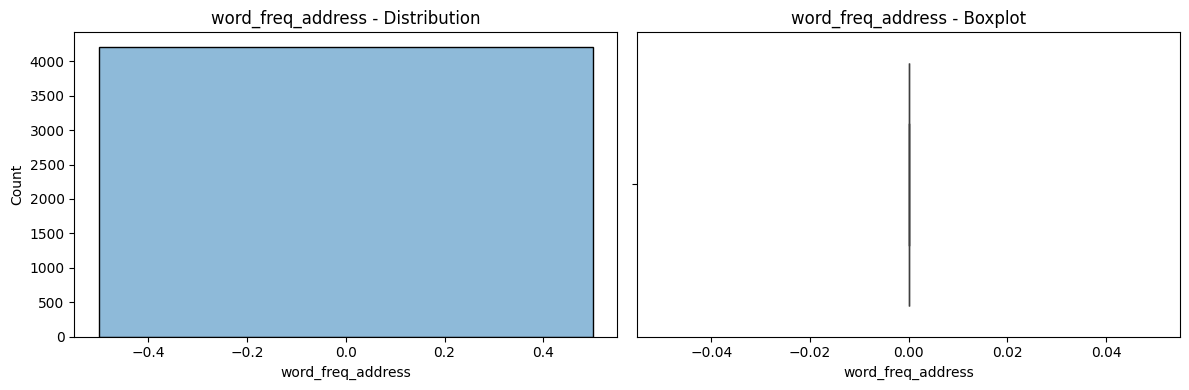

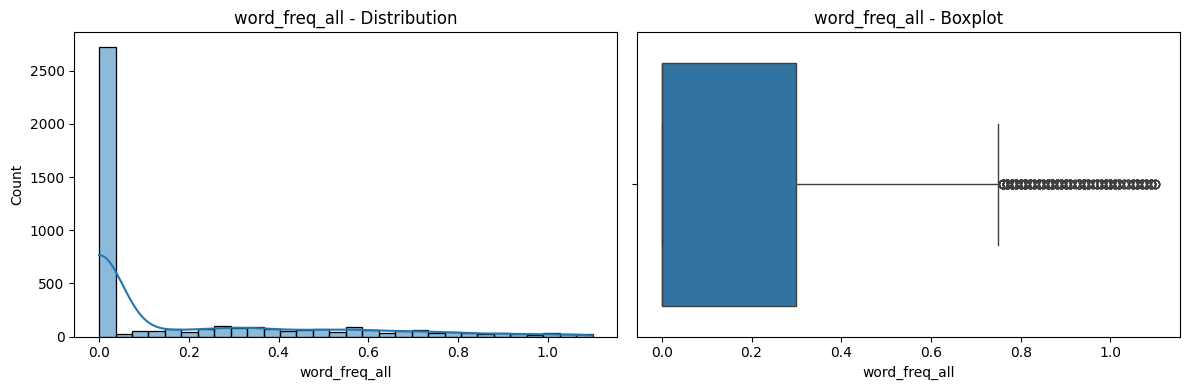

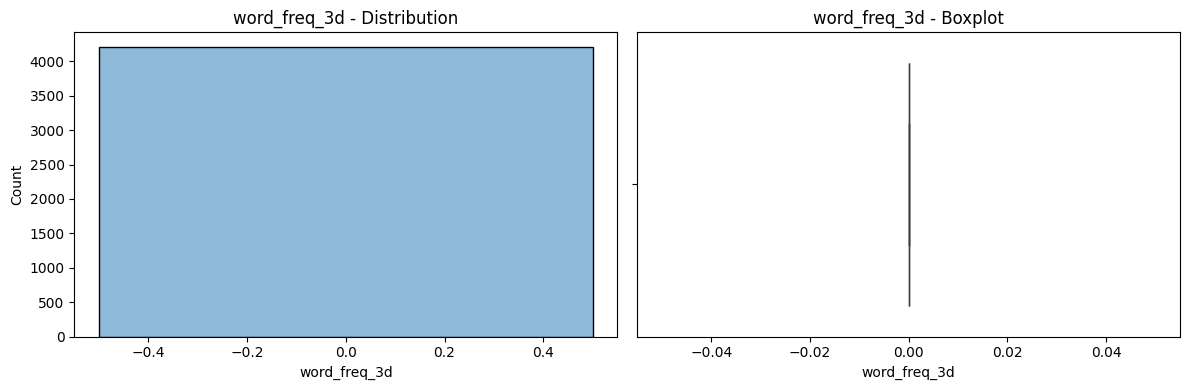

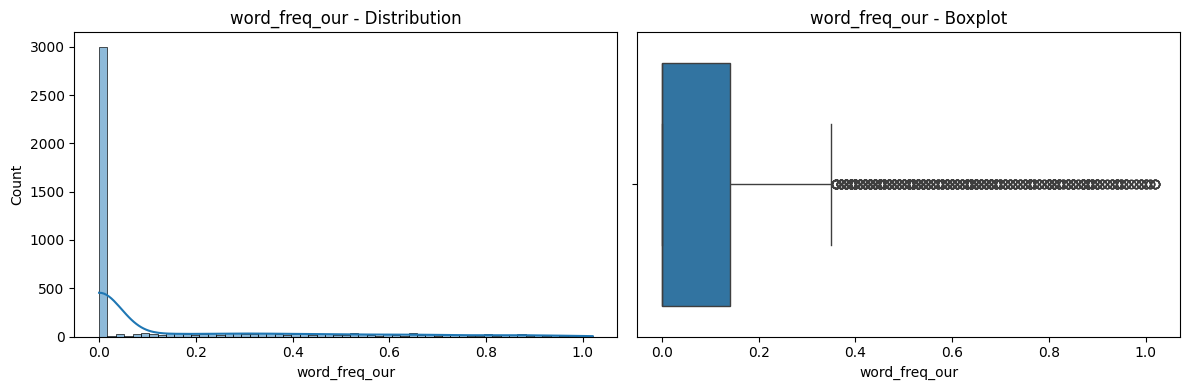

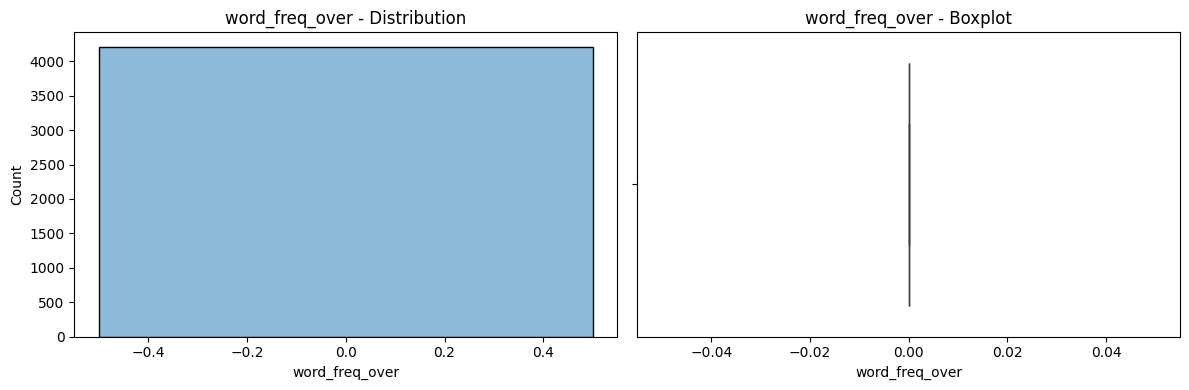

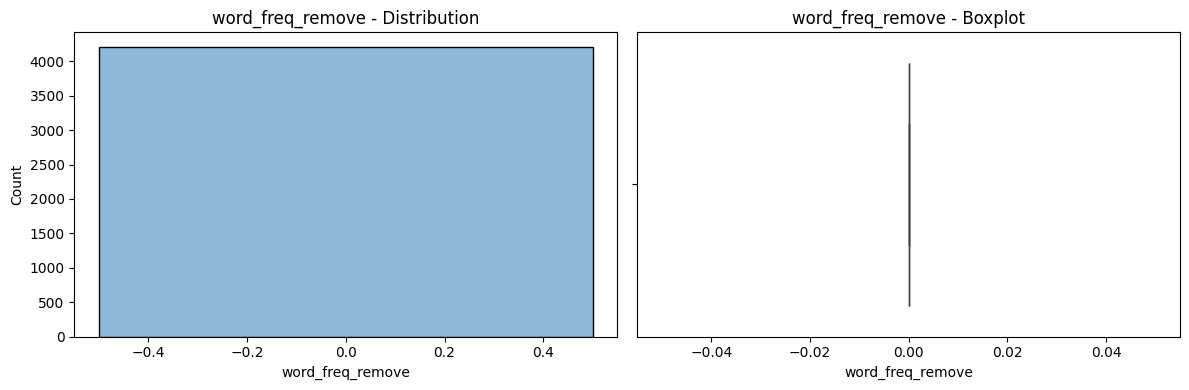

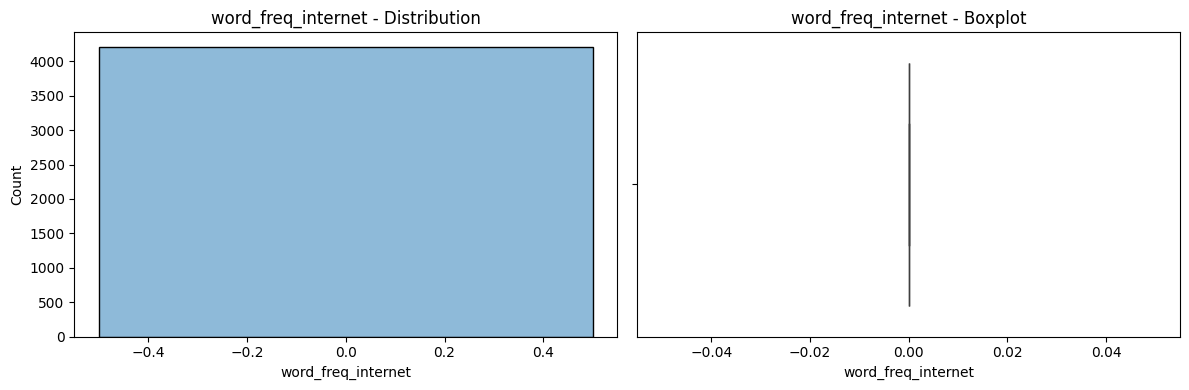

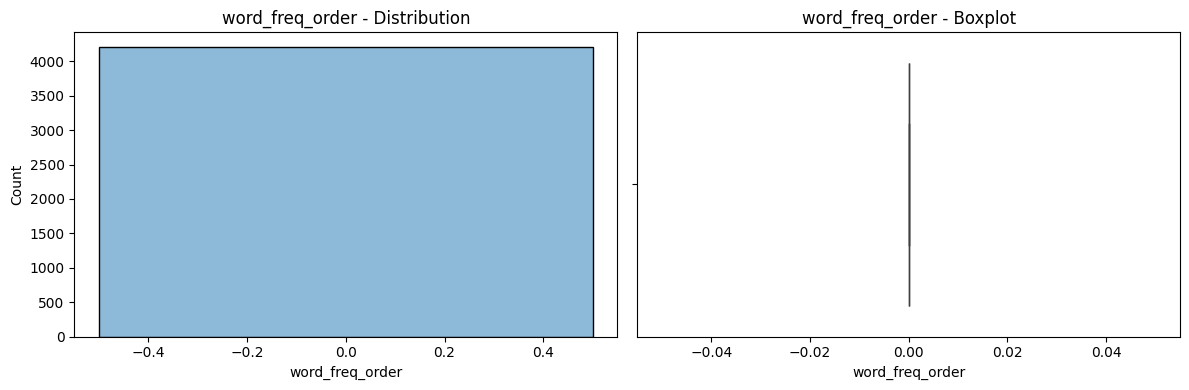

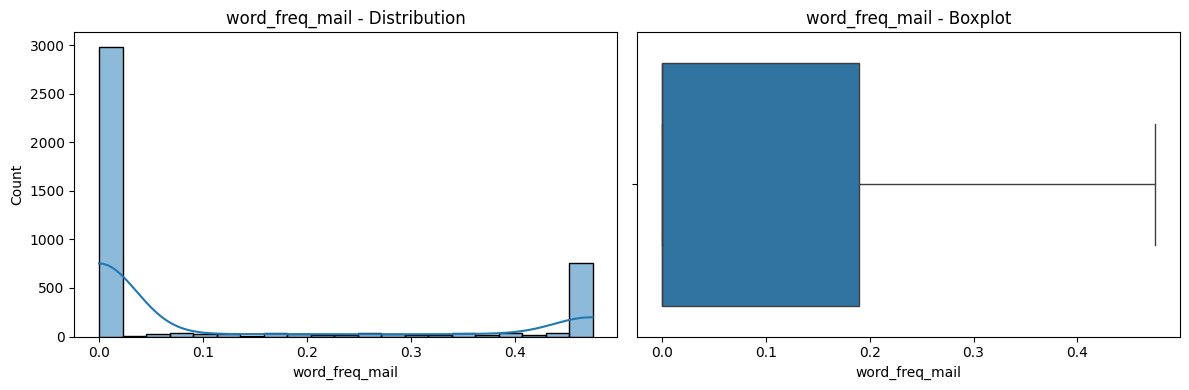

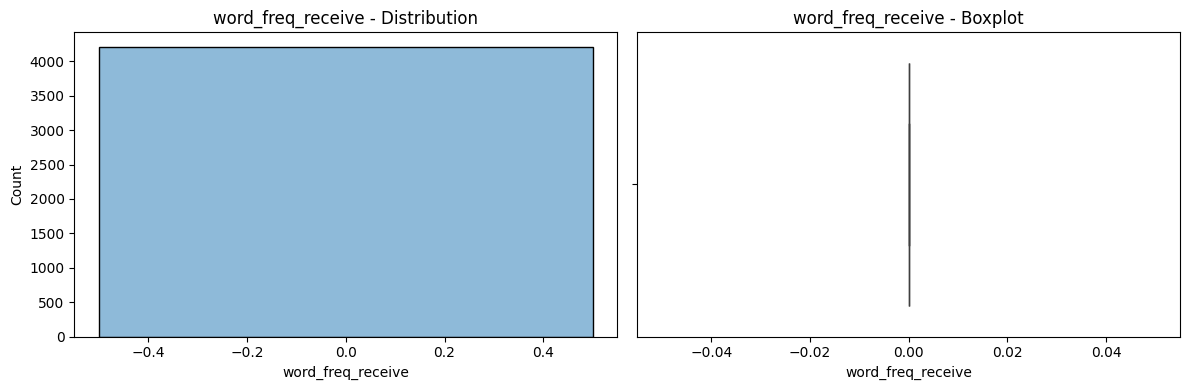

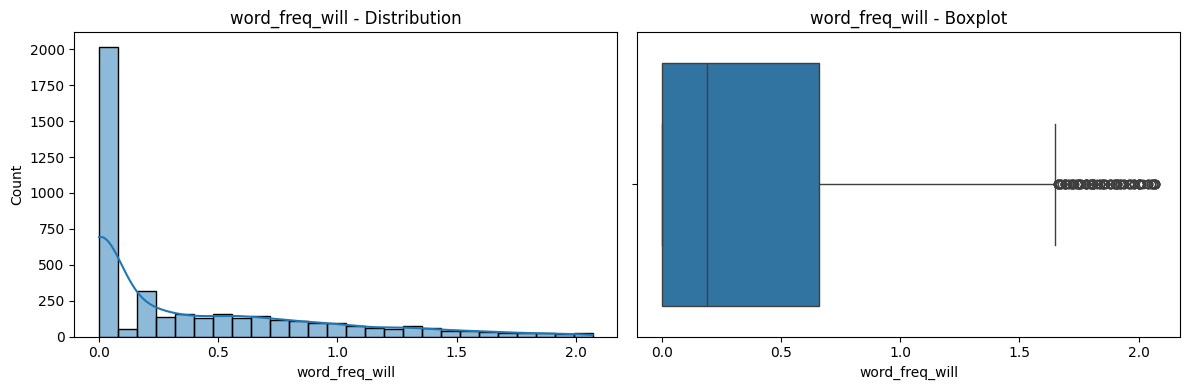

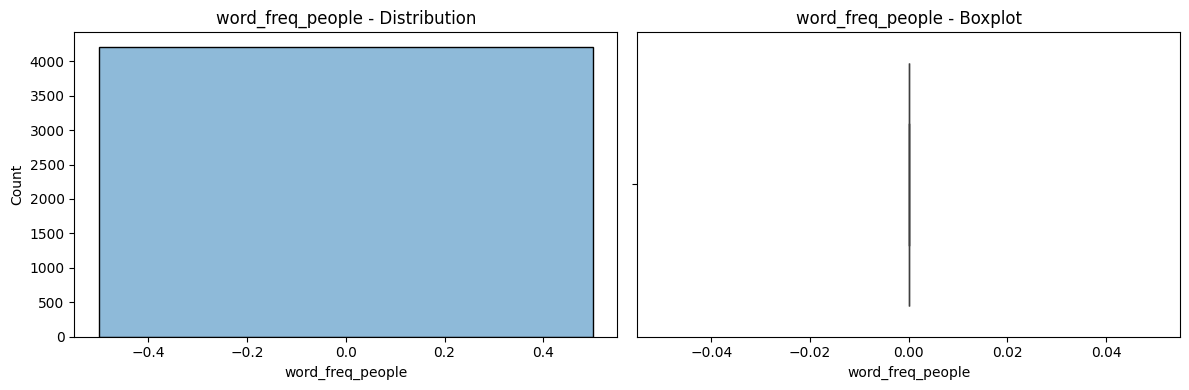

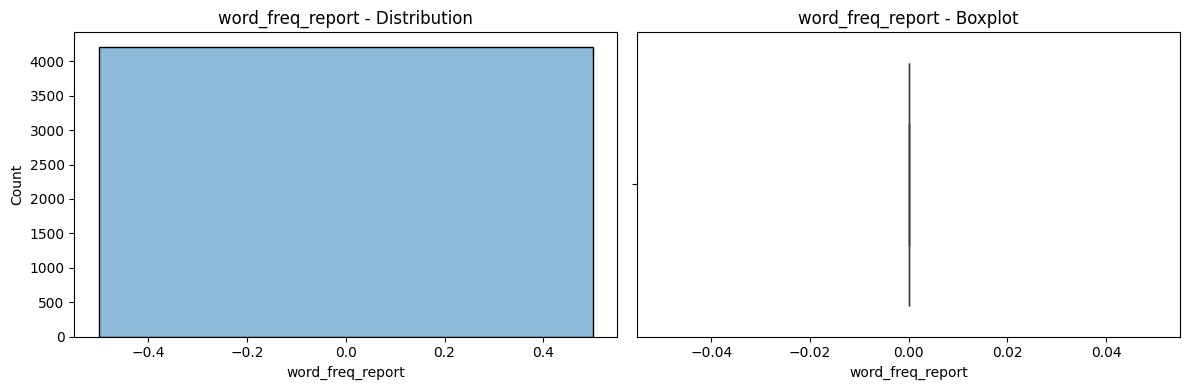

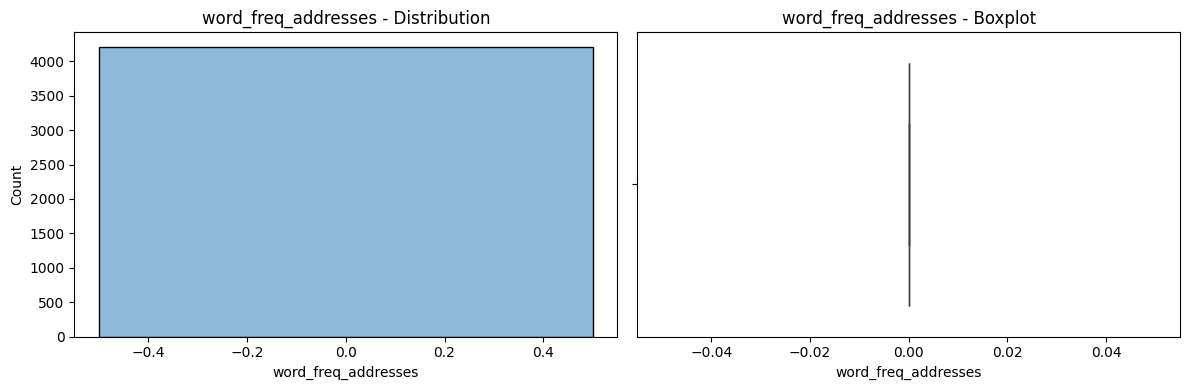

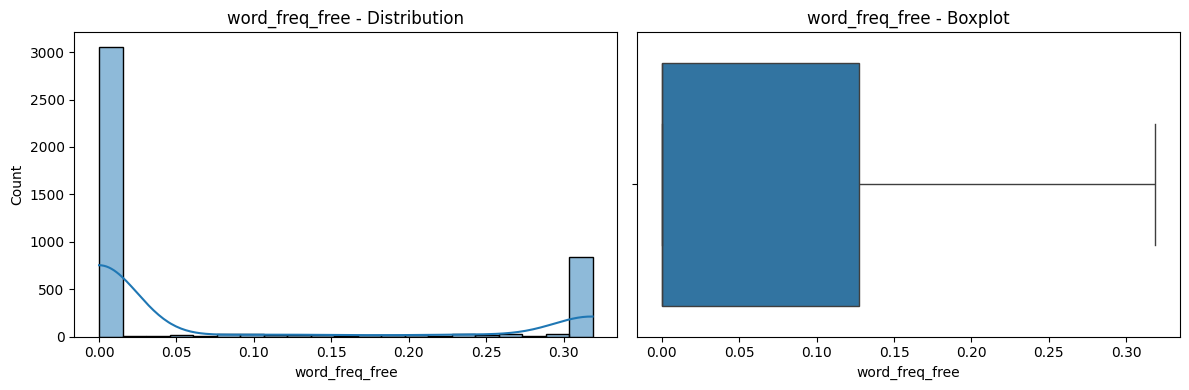

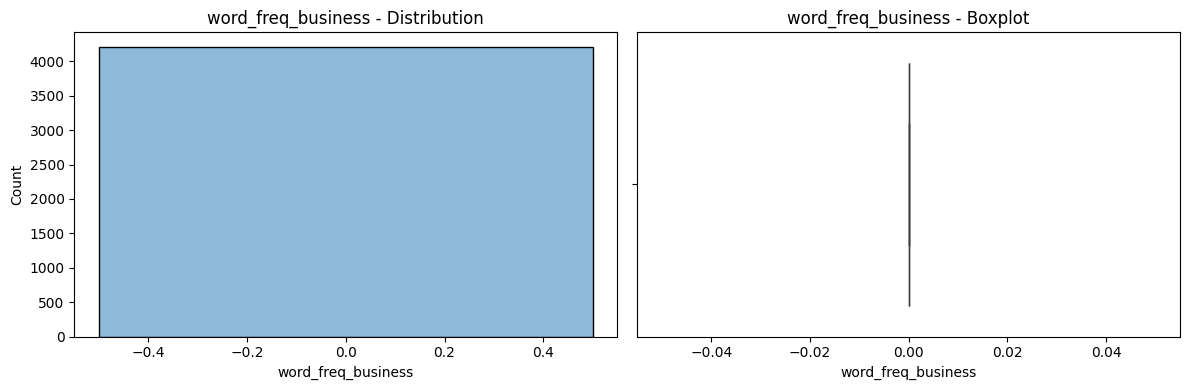

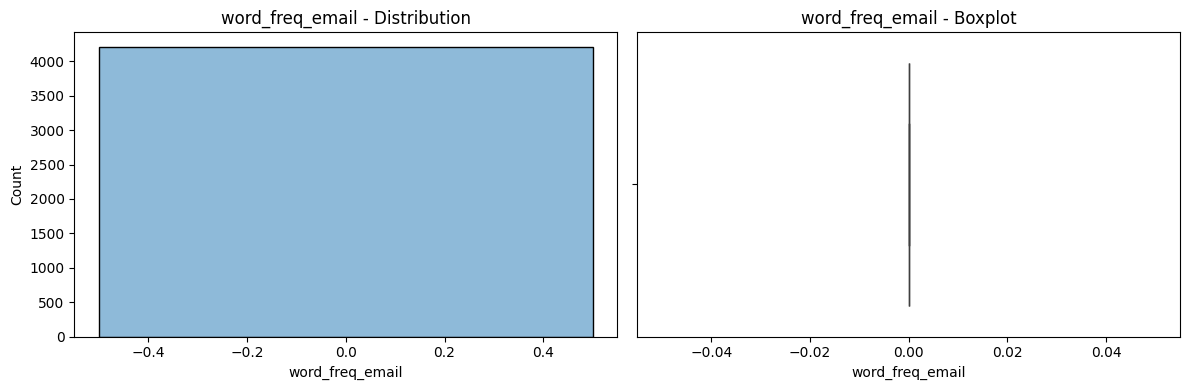

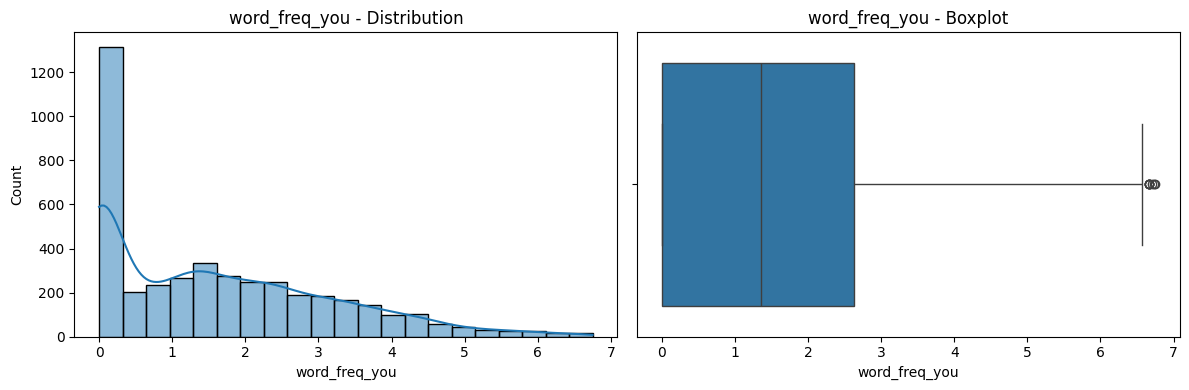

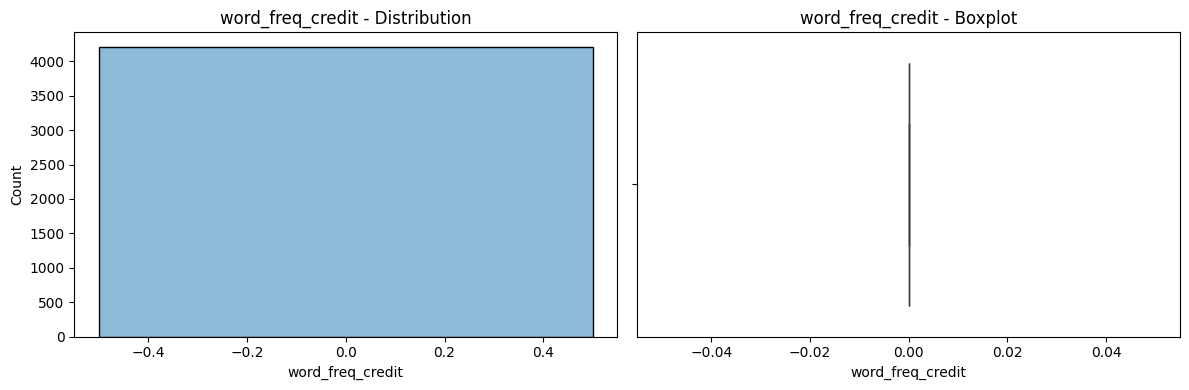

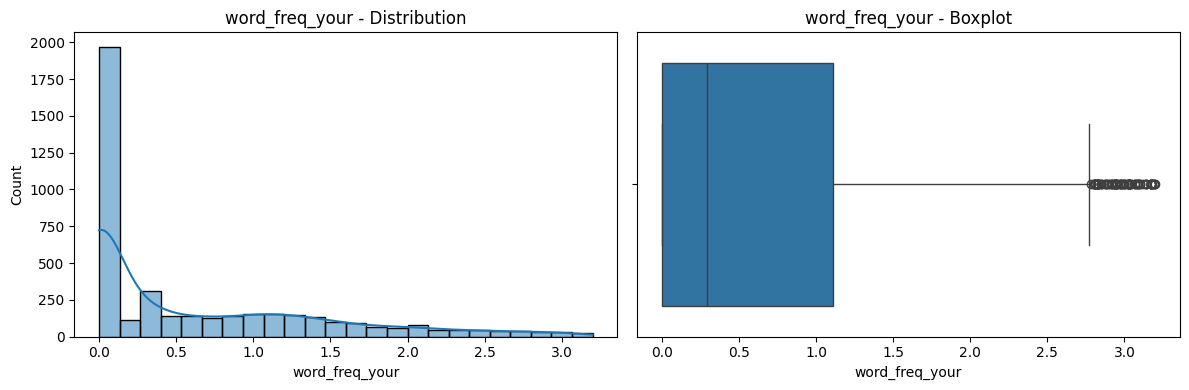

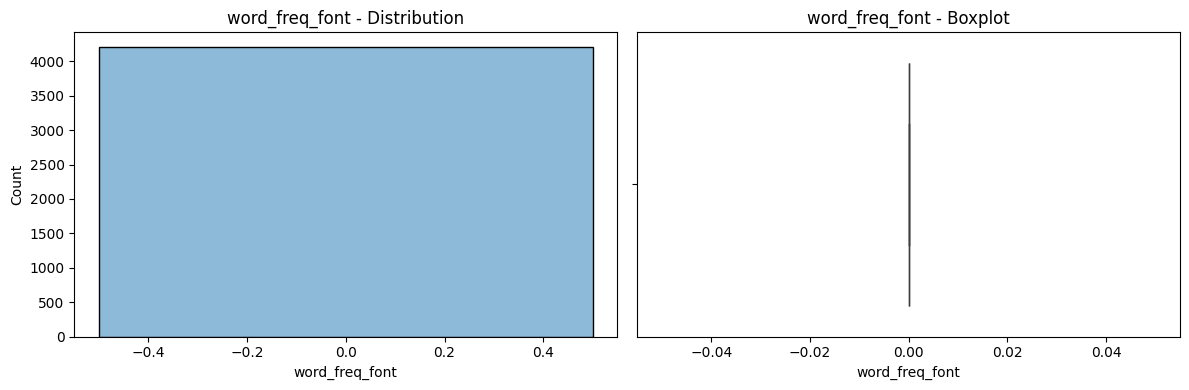

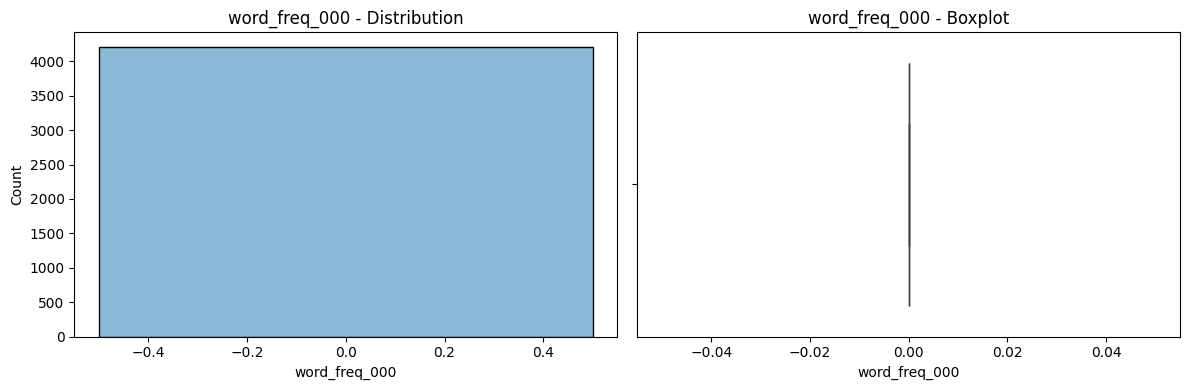

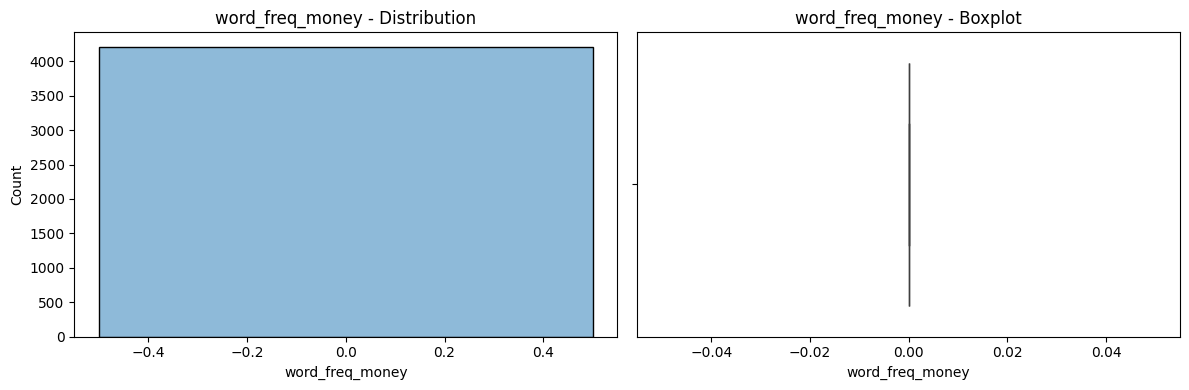

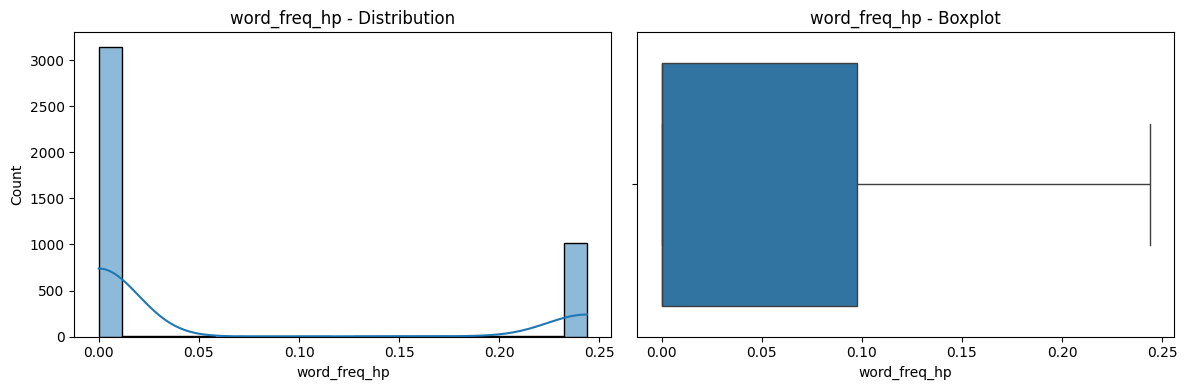

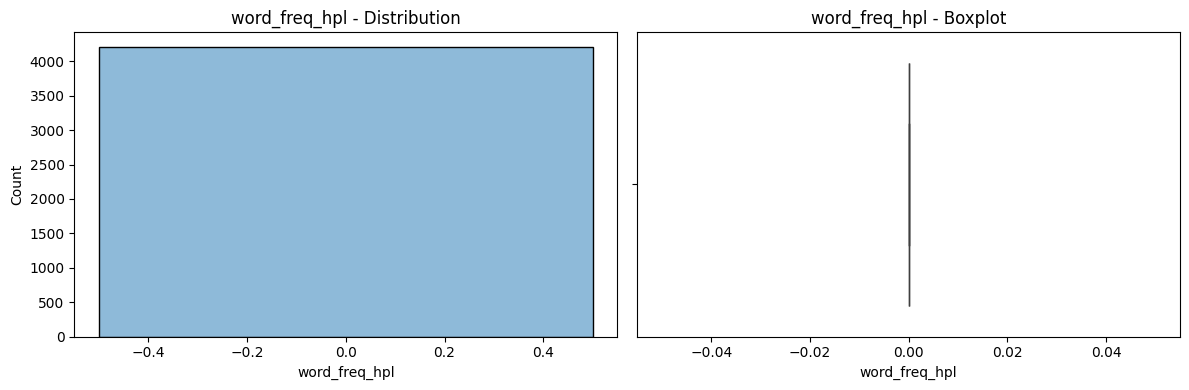

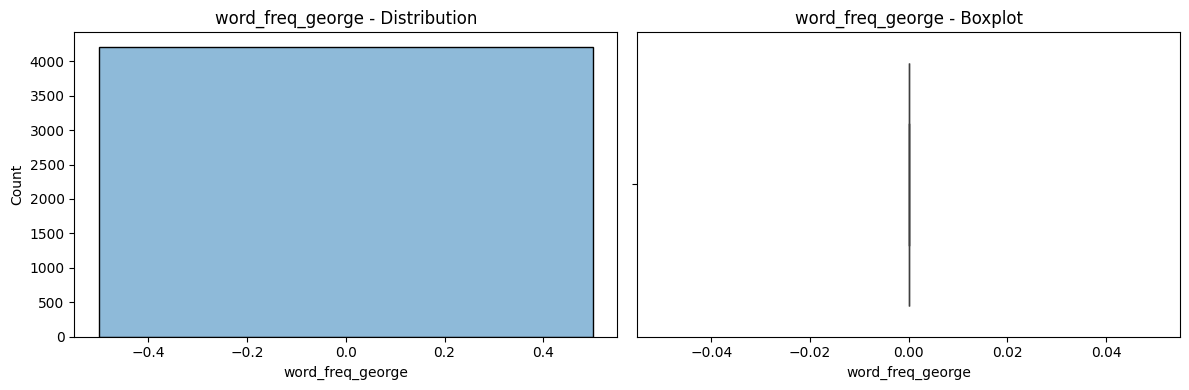

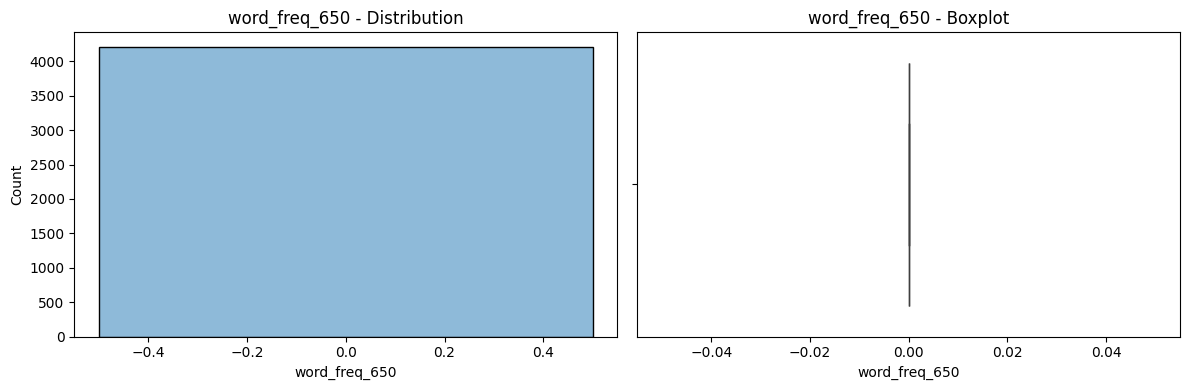

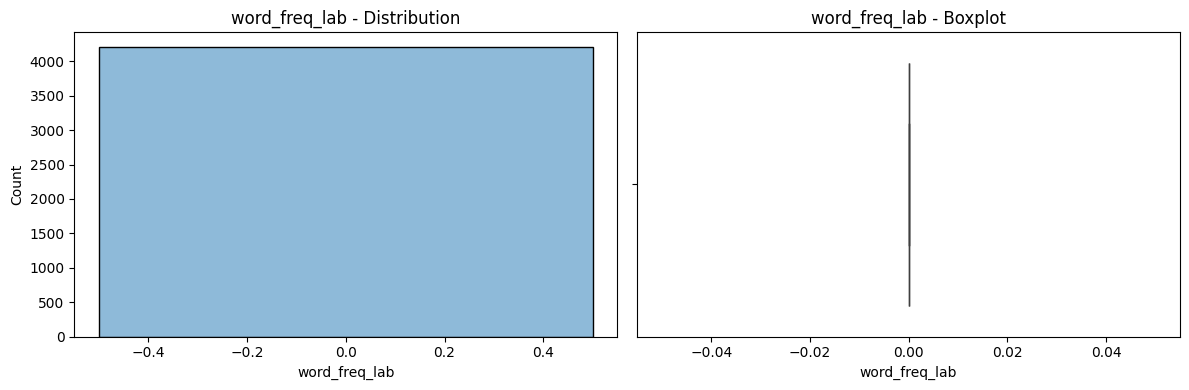

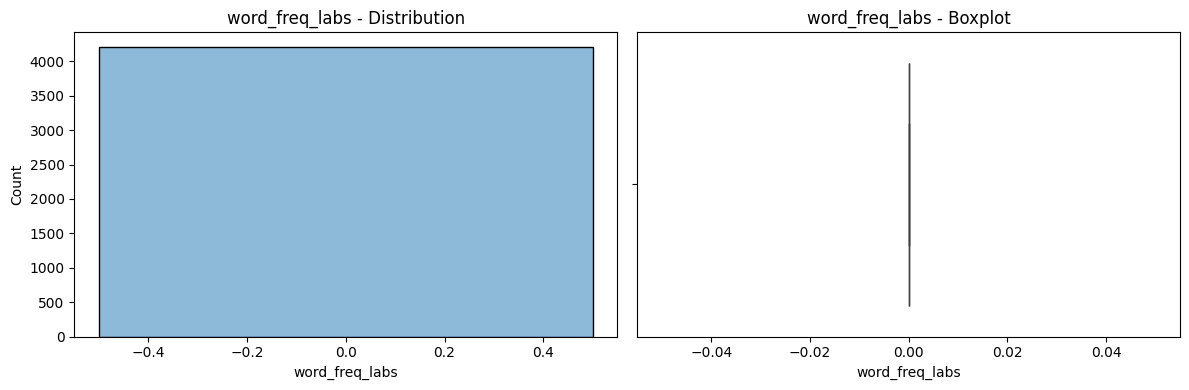

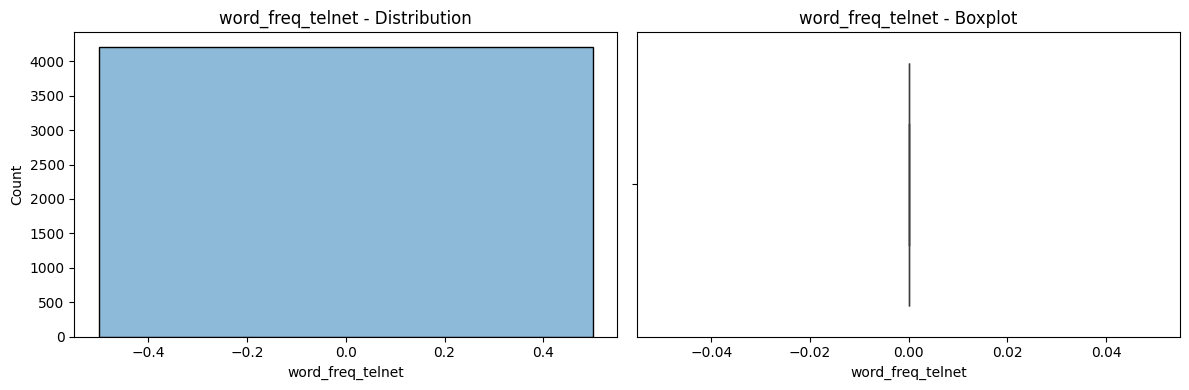

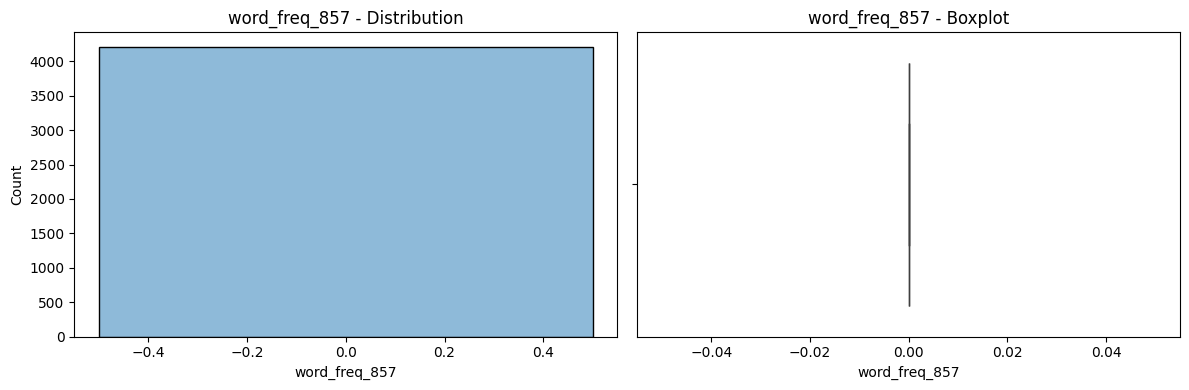

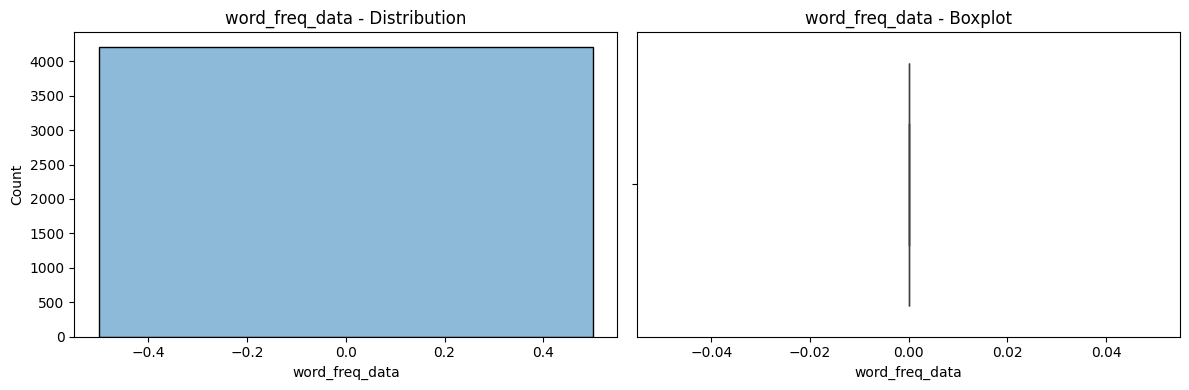

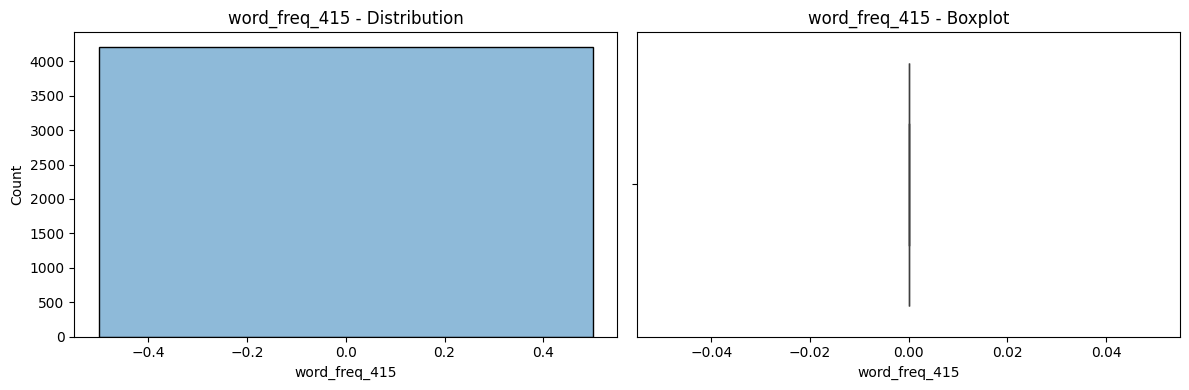

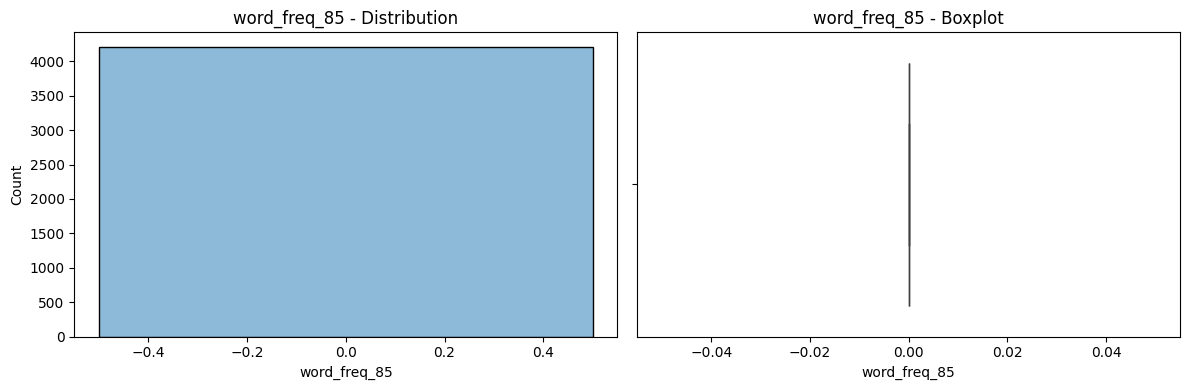

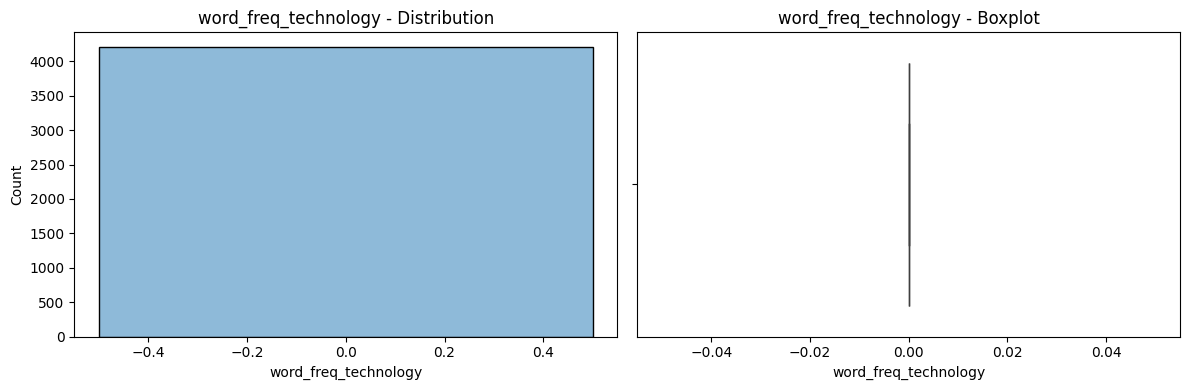

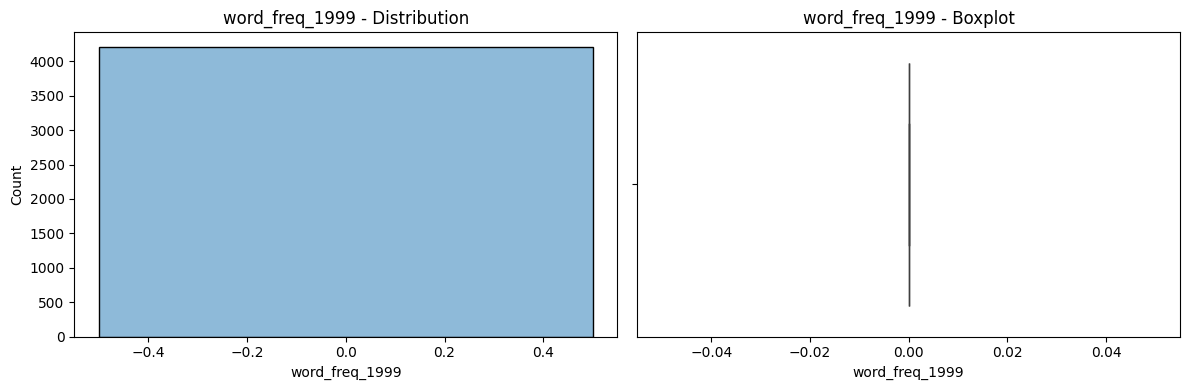

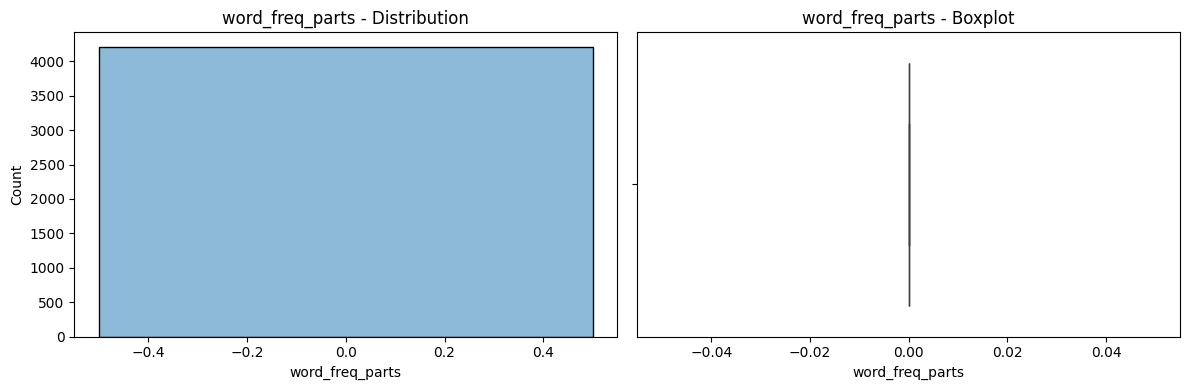

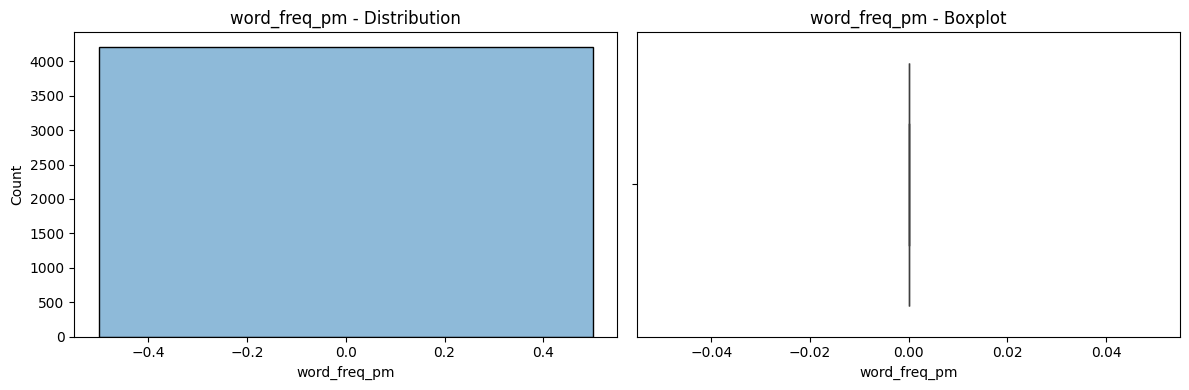

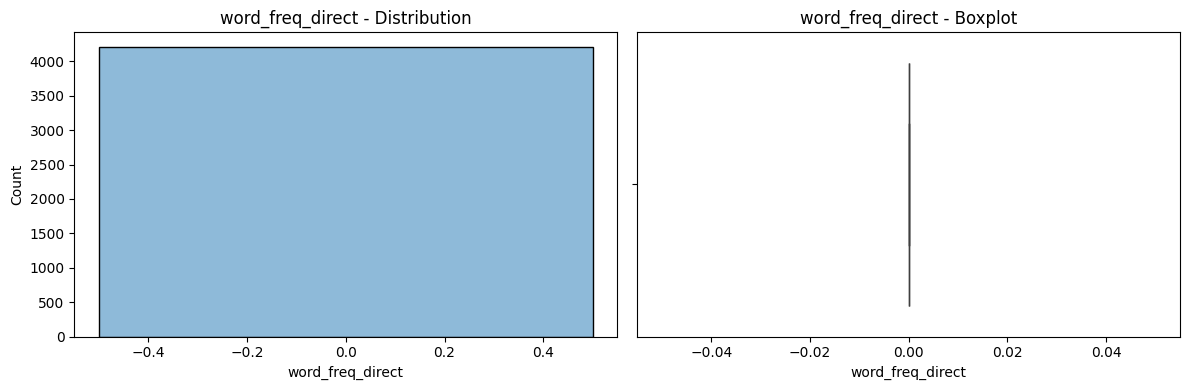

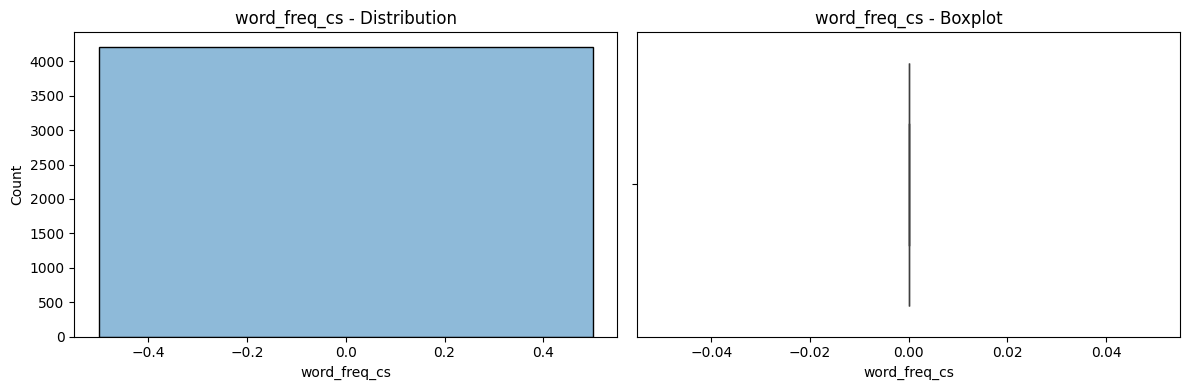

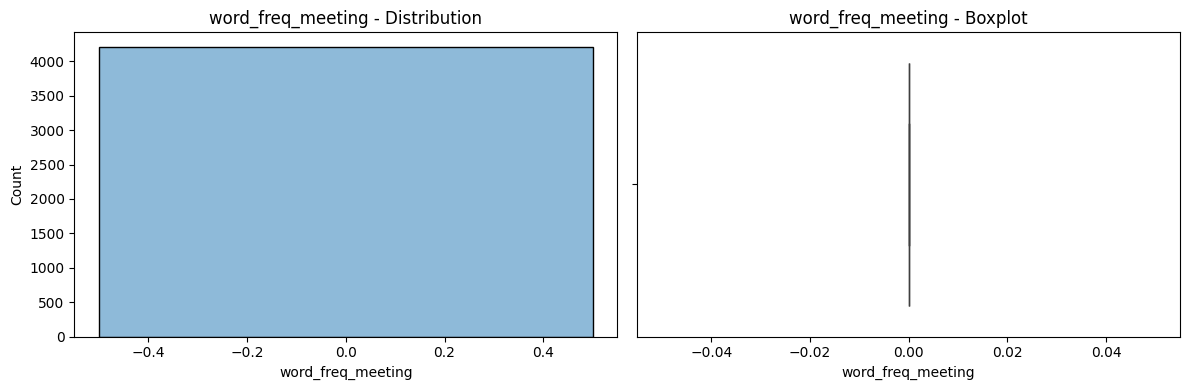

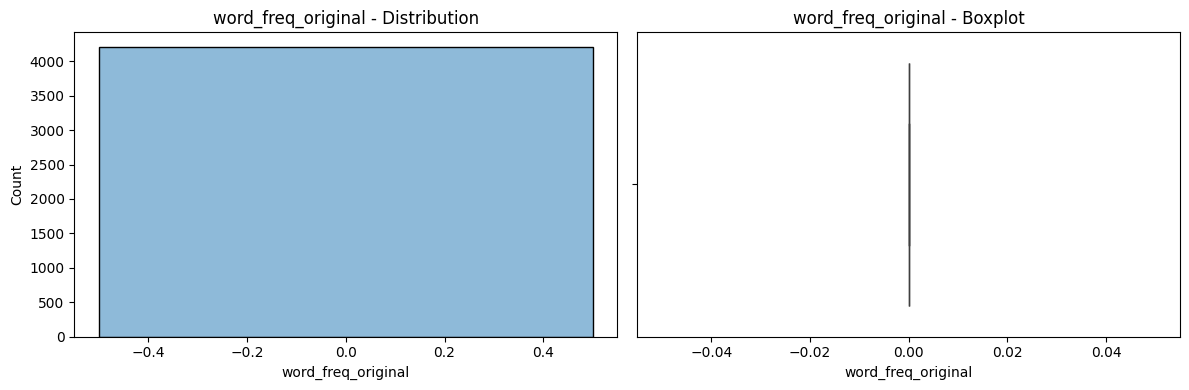

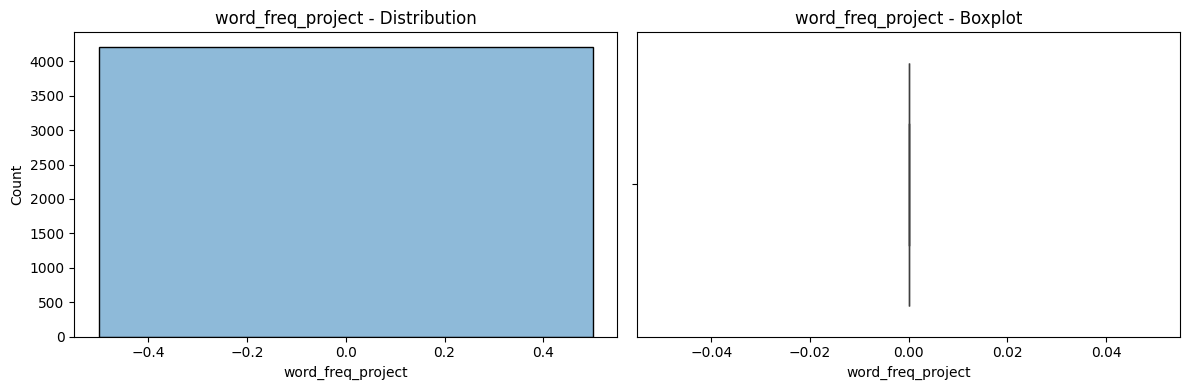

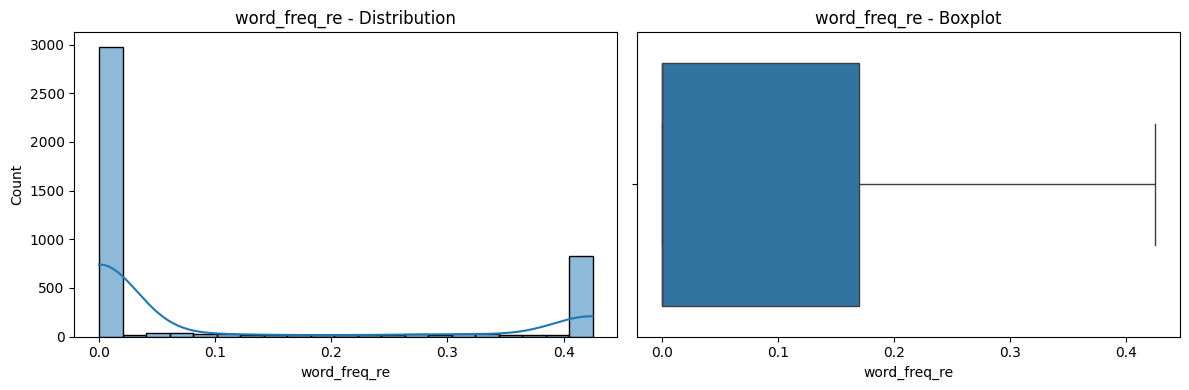

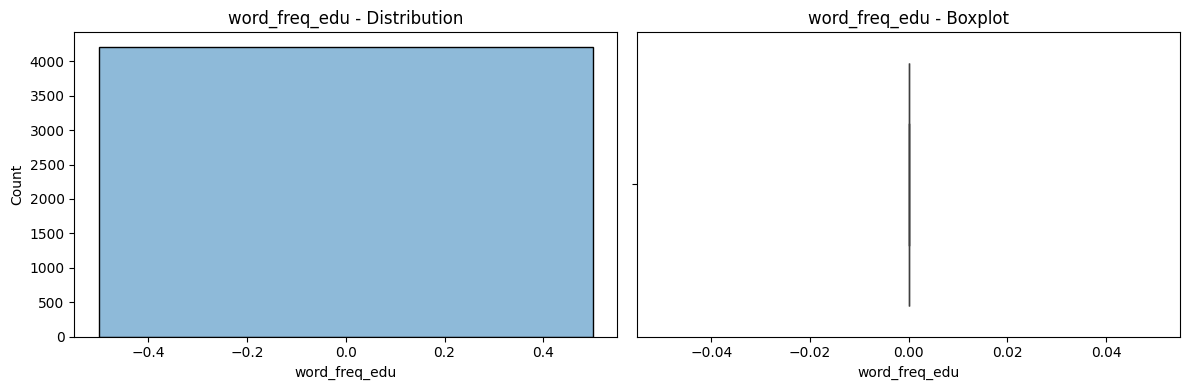

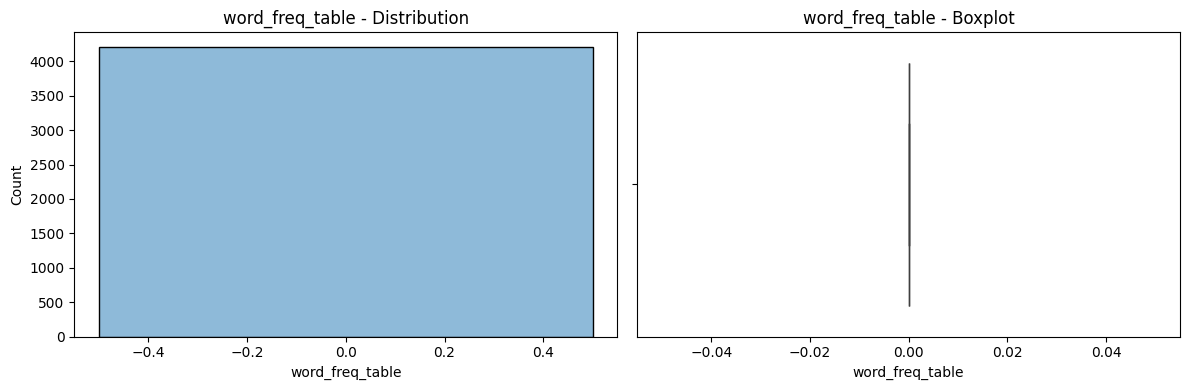

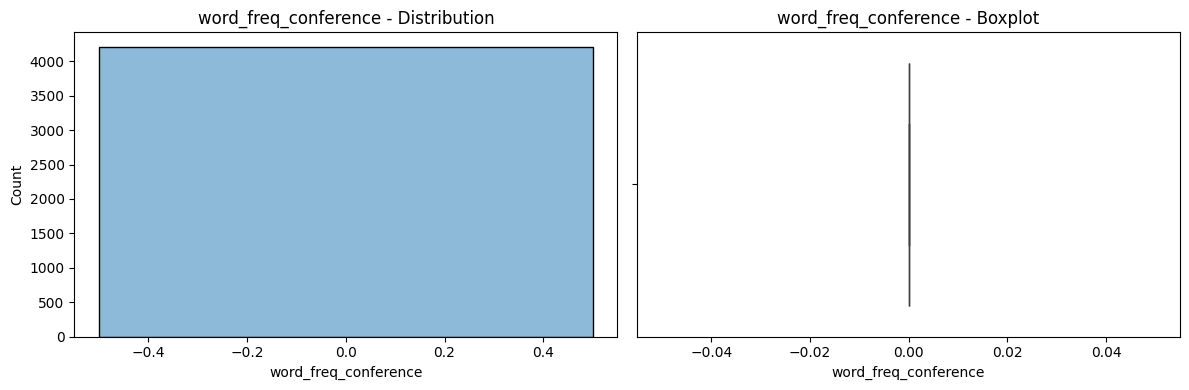

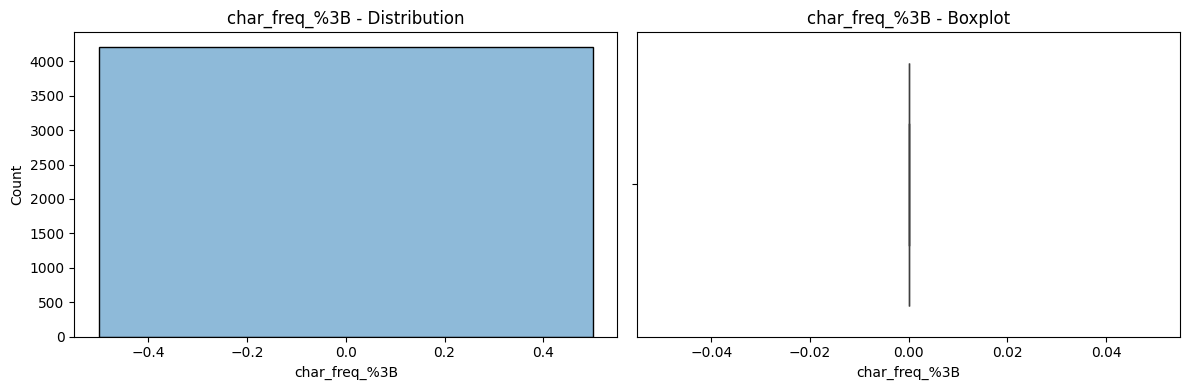

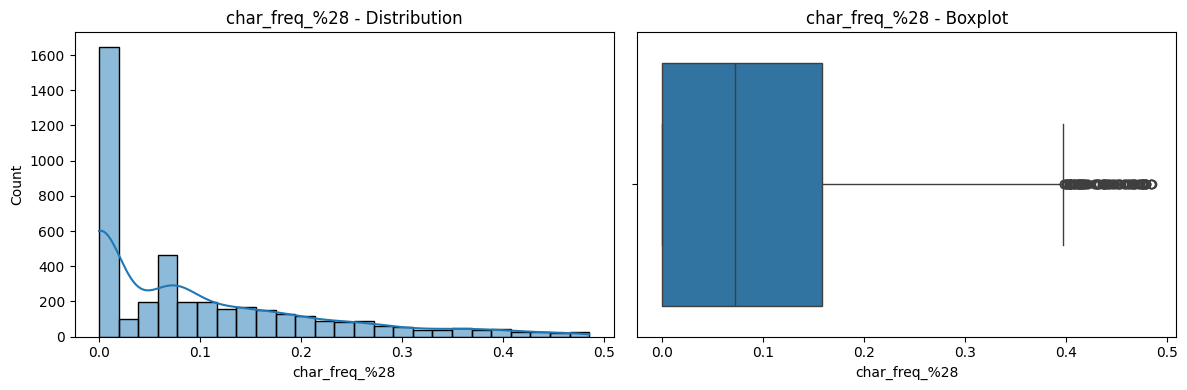

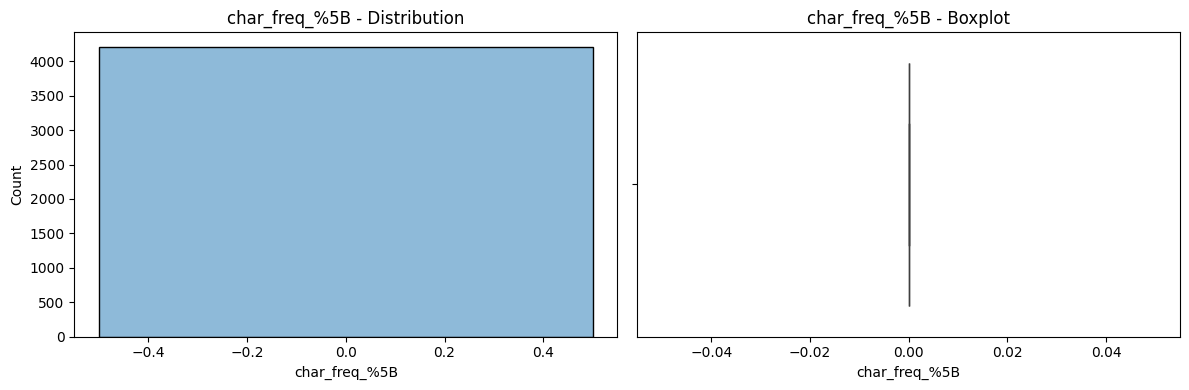

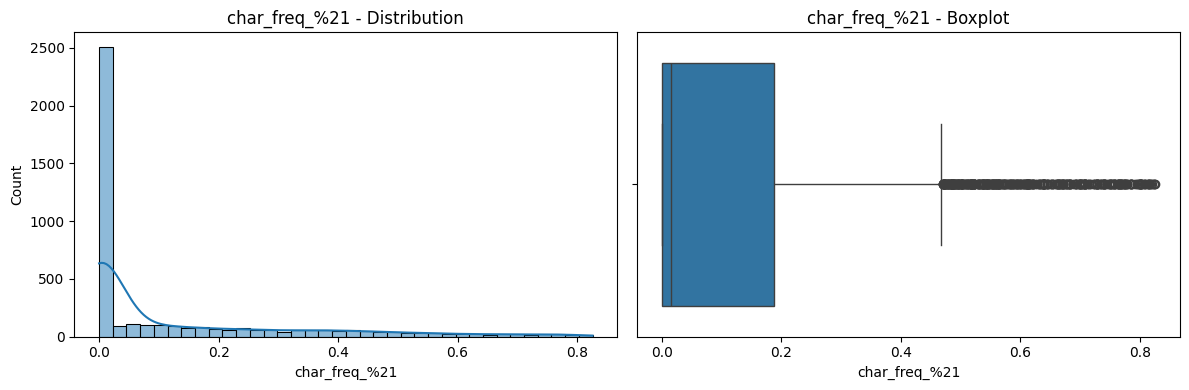

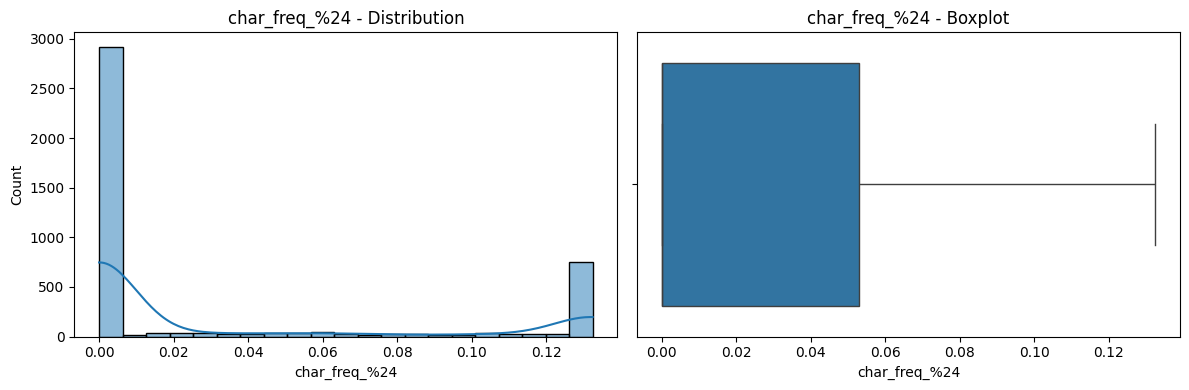

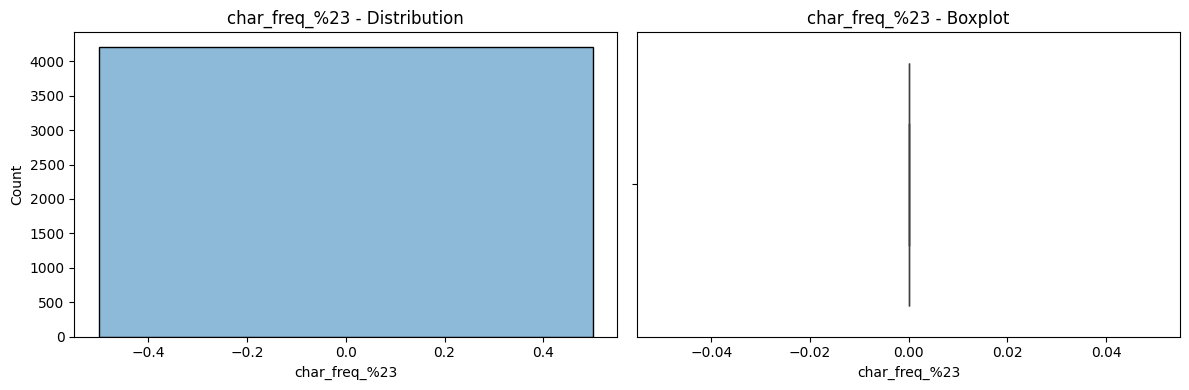

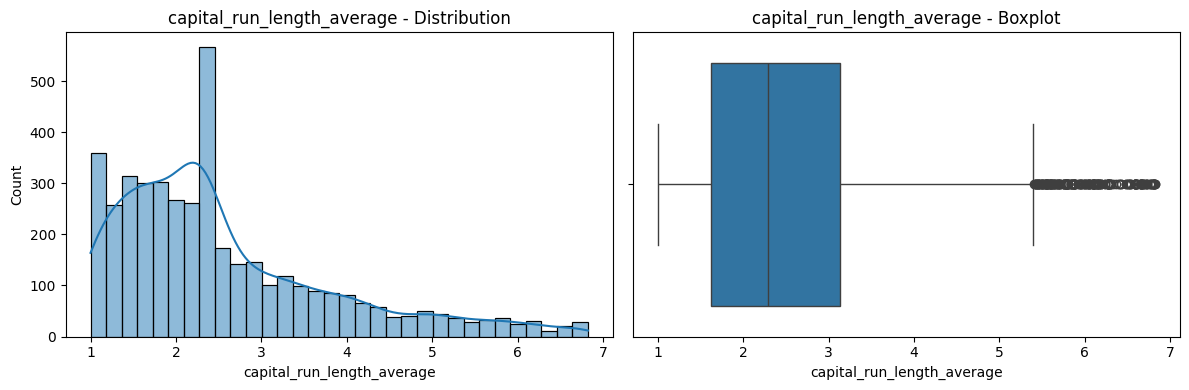

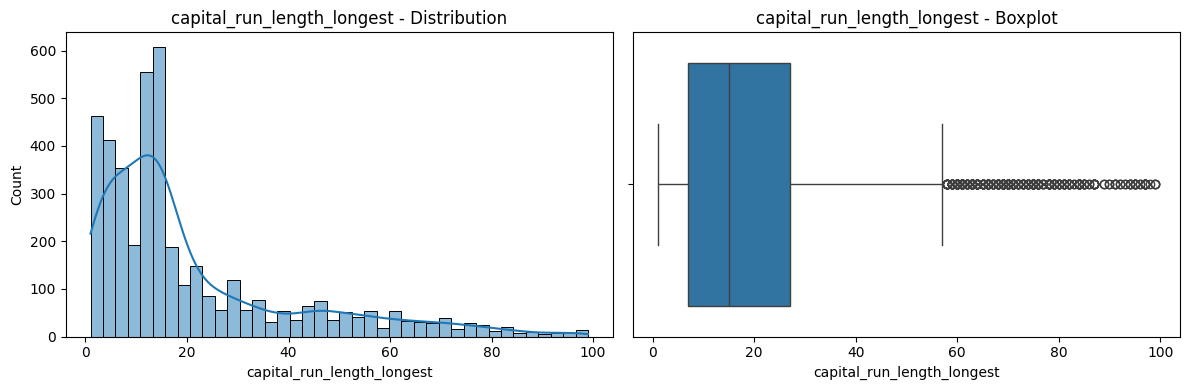

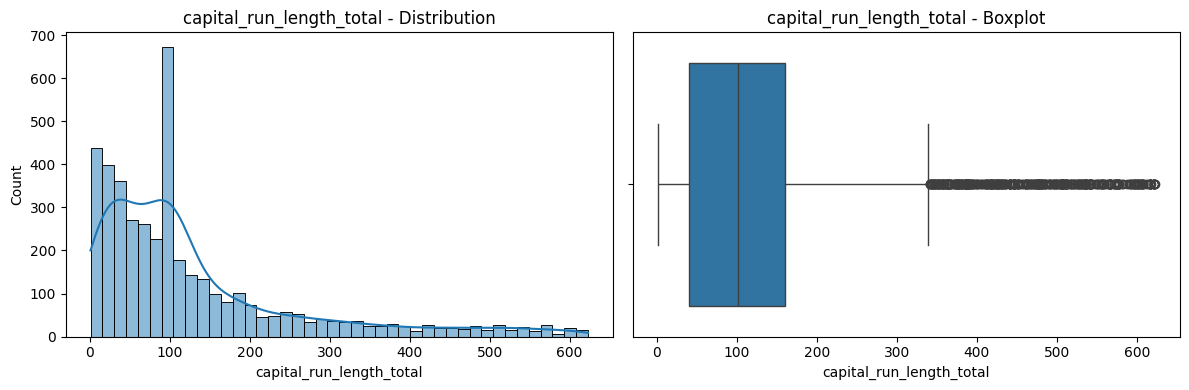

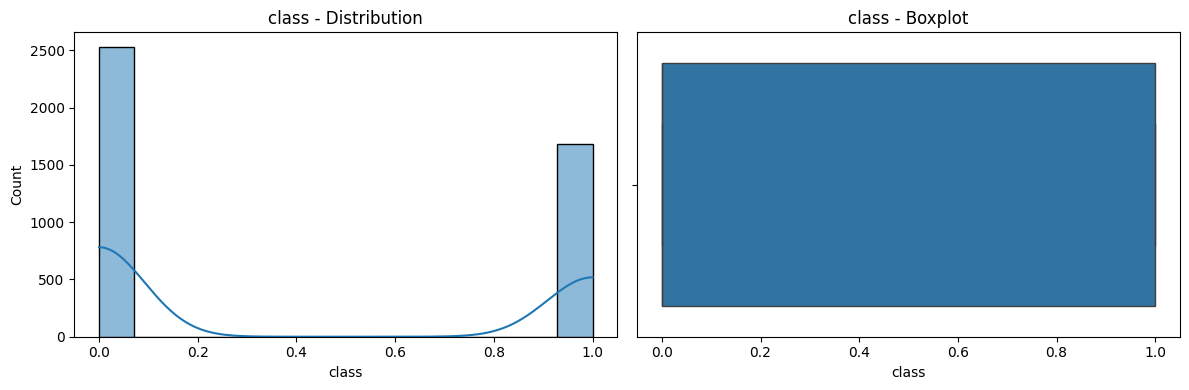

------------------------------------------------------------
NUMERICAL FEATURE TRANSFORMATION
word_freq_make: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_address: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_all: skewness = 1.5364612168082457
Highly skewed and non-negative.
Applied log1p transformation.
word_freq_3d: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_our: skewness = 1.9034446261799778
Highly skewed and non-negative.
Applied log1p transformation.
word_freq_over: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_remove: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_internet: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_order: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_mail: skewness = 1.2177

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_48392\3500902641.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[[col]] = scaler.fit_transform(df[[col]])
C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_48392\3500902641.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[[col]] = scaler.fit_transform(df[[col]])
C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_48392\3500902641.py:182: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_project: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_re: skewness = 1.1969160372589398
Highly skewed and non-negative.
Applied log1p transformation.
word_freq_edu: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_table: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
word_freq_conference: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
char_freq_%3B: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
char_freq_%28: skewness = 1.251726043611477
Highly skewed and non-negative.
Applied log1p transformation.
char_freq_%5B: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
char_freq_%21: skewness = 1.684601276304169
Highly skewed and non-negative.
Applied log1p transformation.
char_freq_%24: skewness = 1.2287872910262543
Highly ske

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_48392\3500902641.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[[col]] = scaler.fit_transform(df[[col]])
C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_48392\3500902641.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[[col]] = scaler.fit_transform(df[[col]])
C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_48392\3500902641.py:182: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

In [6]:
df_spam = pd.read_csv("spambase_csv.csv")
df_spam = eda(df_spam)